# Measuring emission line fluxes

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [9]:
# read the data
import pandas as pd
galname = 'J2101'
j2101 = pd.read_csv(galname + '.csv')

wave = j2101['wave'].to_numpy()
flux = j2101['flux'].to_numpy()
err = j2101['noise'].to_numpy()
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise


# Main lines

# [NII]6548 + Ha + [NII]6584
select = (wave > 7810) * (wave < 7900)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5975) * (wave < 6010)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 8730) * (wave < 8815)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# HeI7065
select = (wave > 8435) * (wave < 8480)
hei_7065 = SpecPiece('hei7065', wave[select], flux[select], err[select])

# HeI6678
select = (wave > 7950) * (wave < 8025)
hei_6678 = SpecPiece('hei6678', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 8000) * (wave < 8100)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# HeI5875
select = (wave > 6990) * (wave < 7070)
hei_5875 = SpecPiece('hei5875', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 6850) * (wave < 6920)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5800) * (wave < 5835)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# HeI4471
select = (wave > 5320) * (wave < 5380)
hei_4471 = SpecPiece('hei4471', wave[select], flux[select], err[select])

# Hg
select = (wave > 5170) * (wave < 5215)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4875) * (wave < 4940)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4850) * (wave < 4900)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 4440) * (wave < 4480)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])


# High ionization lines

# No [SIII]9532 and [SIII]9069 detections

# [SIII]9069
select = (wave > 10800) * (wave < 10900)
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 7500) * (wave < 7590)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 7500) * (wave < 7590)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5910) * (wave < 5960)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# HeII4686
select = (wave > 5580) * (wave < 5630)
heii_4686 = SpecPiece('heii4686', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 5210) * (wave < 5230)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4615) * (wave < 4643)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

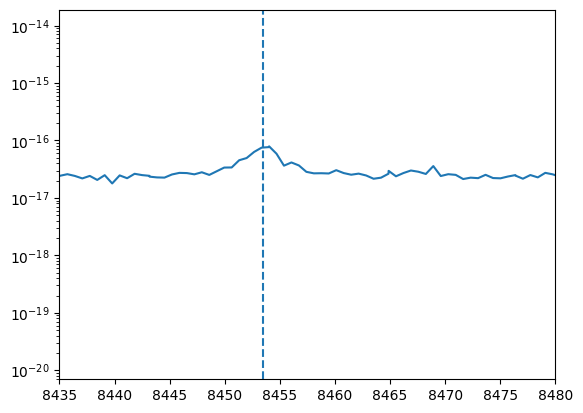

In [10]:
plt.plot(wave, flux)
plt.xlim(8435, 8480)
plt.axvline((1 + z_BN[igal])*wave_cat['HeI7065'], ls='--')
plt.yscale('log')

---

# Two component model fit for [OIII] 4959

In [11]:
m = 8.5005e-05
n = 0.08658081

sigma_arc_4959 = (m * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n

# [OIII]4959

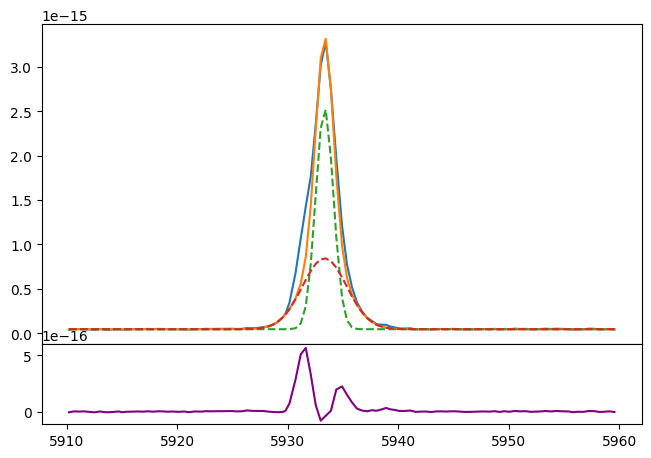

In [12]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 4.5e-17

oiiib_nar = gaussian(oiii_4959.wavelength, 500e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=0.8)
oiiib_brd = gaussian(oiii_4959.wavelength, 400e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=2.0)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
#ax.set_yscale('log')

In [13]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal])
params_oiii_4959.add('z_brd', value=z_BN[igal])
params_oiii_4959.add('sigma_nar', value=0.8, min=0.)
params_oiii_4959.add('sigma_brd', value=2.0, min=0.)
params_oiii_4959.add('Oiiib_nar', value=500e-17, min=0.)
params_oiii_4959.add('Oiiib_brd', value=400e-17, min=0.)
params_oiii_4959.add('bkg', value=4.5e-17, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [14]:
np.random.seed(2101)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 125.89it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [200.38194017  53.95287739 222.98923672 203.37006763 218.47478797
 209.95323465  95.3828311 ]


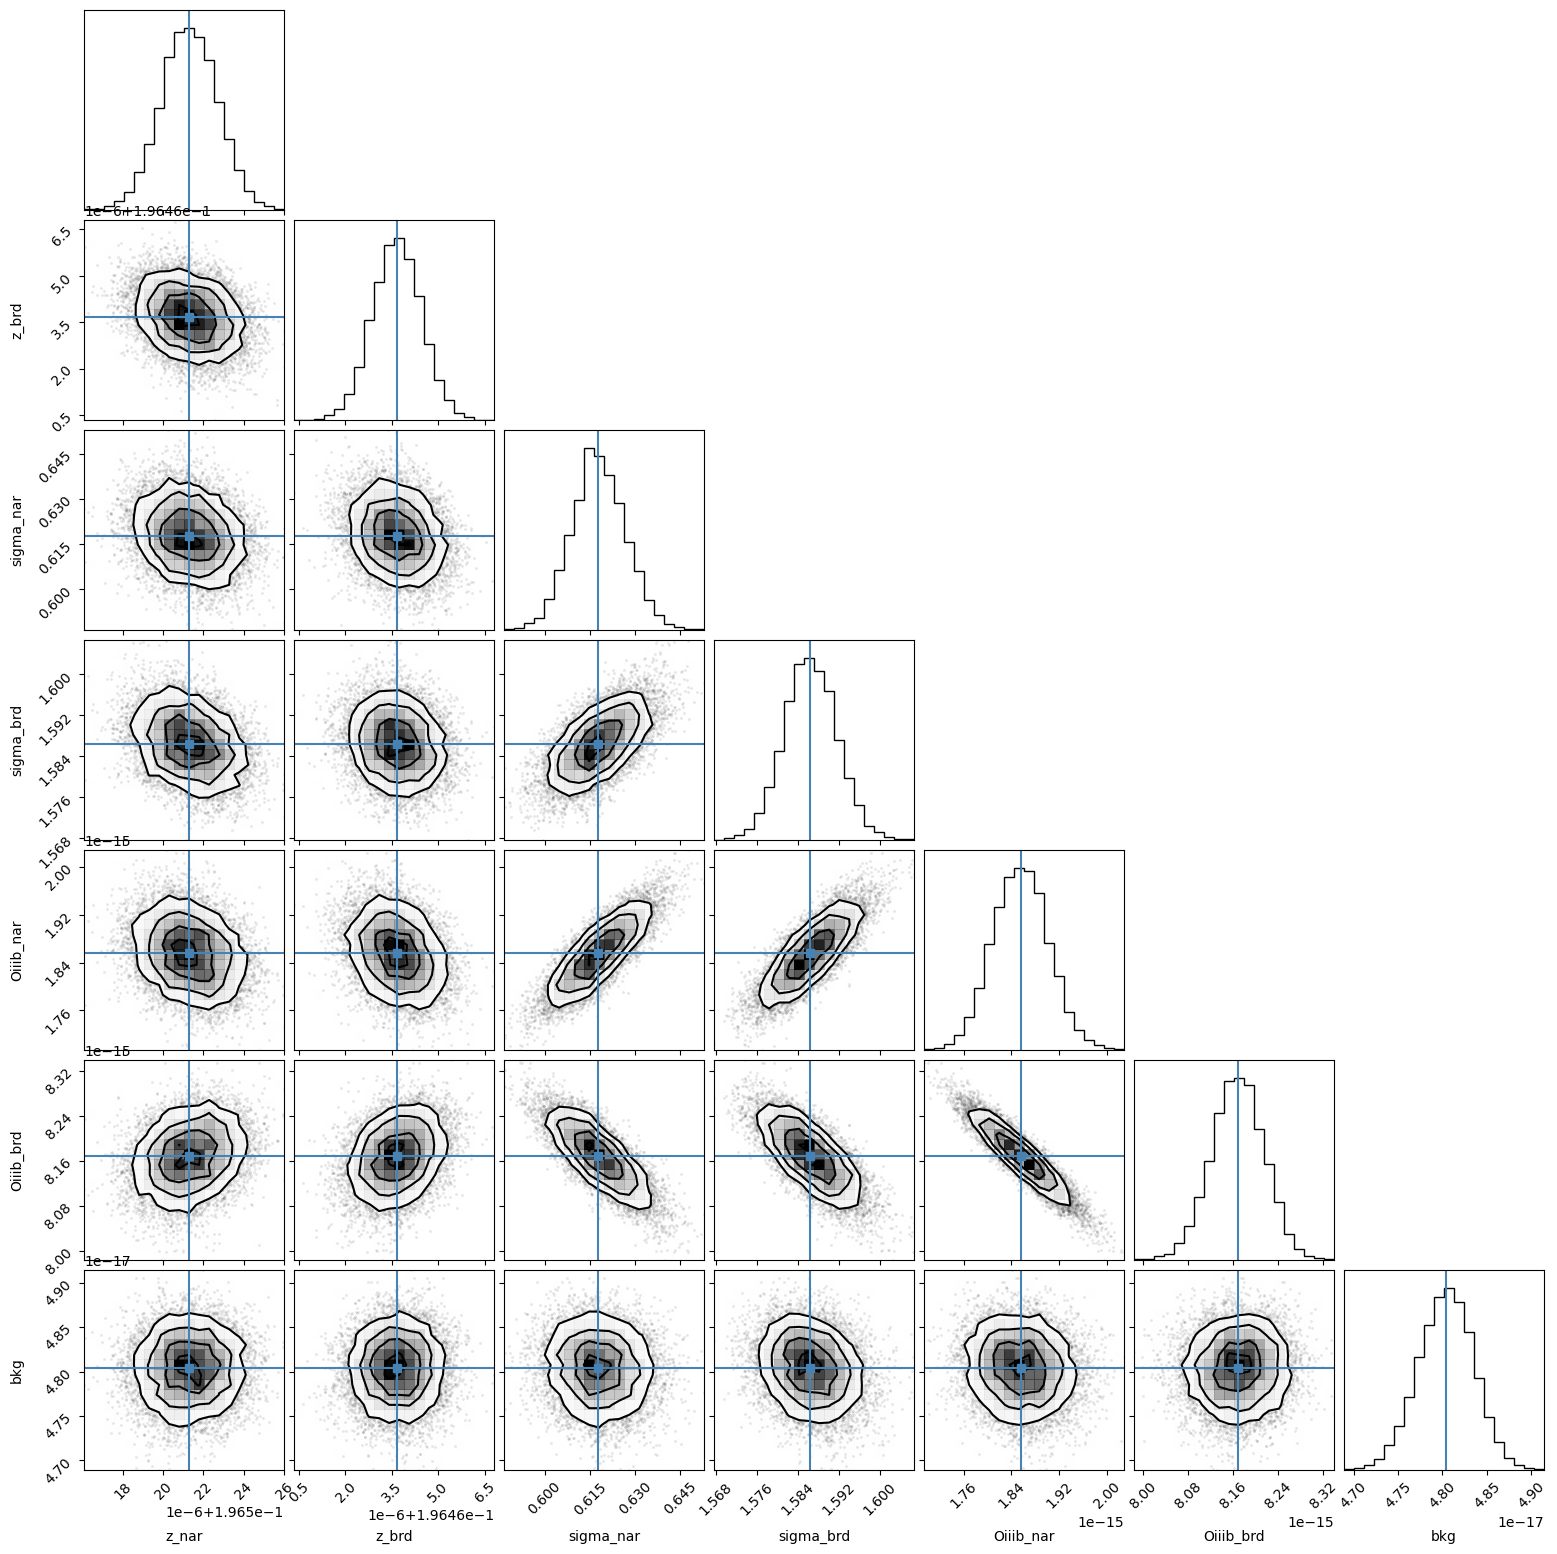

In [15]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [16]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19652130,1.3699e-06,(0.00%),0.1965,-inf,inf,True
z_brd,0.19646367,7.8570e-07,(0.00%),0.1965,-inf,inf,True
sigma_nar,0.61768821,0.00885854,(1.43%),0.8,0.00000000,inf,True
sigma_brd,1.58642133,0.00507023,(0.32%),2.0,0.00000000,inf,True
Oiiib_nar,1.8554e-15,4.6185e-17,(2.49%),5e-15,0.00000000,inf,True
Oiiib_brd,8.1683e-15,4.6680e-17,(0.57%),4e-15,0.00000000,inf,True
bkg,4.8045e-17,3.0925e-19,(0.64%),4.5e-17,0.00000000,inf,True


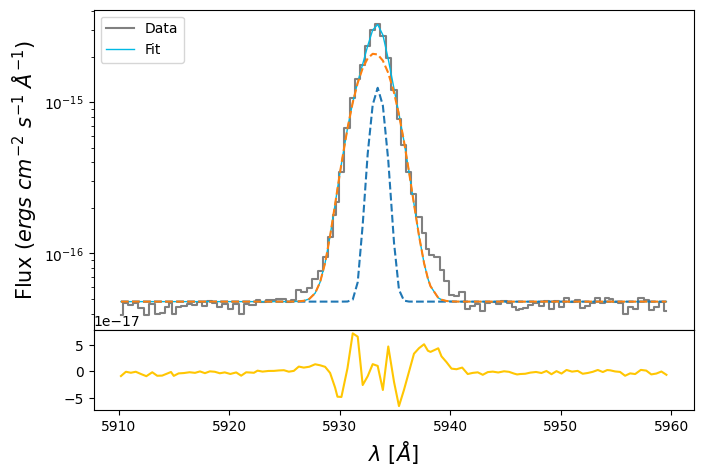

In [17]:
oiiib_nar_flux = out_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_brd_flux = out_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out_oiii_4959.flatchain.Oiiib_brd.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
bkg_oiii_4959_std = out_oiii_4959.flatchain.bkg.std()

z_nar_oiii_4959 = out_oiii_4959.flatchain.z_nar.mean()
z_nar_oiii_4959_std = out_oiii_4959.flatchain.z_nar.std()

z_brd_oiii_4959 = out_oiii_4959.flatchain.z_brd.mean()
z_brd_oiii_4959_std = out_oiii_4959.flatchain.z_brd.std()

sigma_nar_oiii_4959 = out_oiii_4959.flatchain.sigma_nar.mean()
sigma_nar_oiii_4959_std = out_oiii_4959.flatchain.sigma_nar.std()

sigma_brd_oiii_4959 = out_oiii_4959.flatchain.sigma_brd.mean()
sigma_brd_oiii_4959_std = out_oiii_4959.flatchain.sigma_brd.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [18]:
# Correcting sigma by instrumental broadening

# Intrinsic from the galaxy
sigma_nar_intrinsic = upy.sqrt((ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std)**2) - (sigma_arc_4959**2))
sigma_brd_intrinsic = upy.sqrt((ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std)**2) - (sigma_arc_4959**2)) 

In [19]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(sigma_nar_intrinsic,  wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(sigma_brd_intrinsic,  wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

In [20]:
print('Redshift of the narrow component: {:.4f}'.format(ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))

Redshift of the narrow component: 0.1965+/-0.0000


In [21]:
# Velocities
vel = {'galname': galname,
       'z_nar': z_nar_oiii_4959,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}

vel_catalog_pd = pd.DataFrame(data=vel, index=[0])
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog.csv')

Existent catalog (.csv) file.
Non existent data for J2101, adding new data...
Done.


---

# [NII]6548 + H$\alpha$ + [NII]6584

In [15]:
sigma_arc_ha = (m * wave_cat['Ha']*(1 + z_BN[igal])) + n

sigma_nar_ha = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_ha**2))
sigma_brd_ha = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_ha**2))

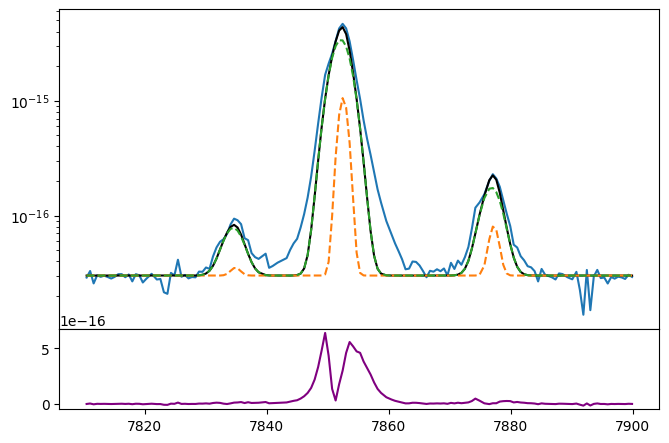

In [16]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 3e-17

ha_nar = gaussian(ha_nii.wavelength, 0.2e-14, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, 1.4e-14, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, 0.01e-15, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, 0.2e-15, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, 0.1e-15, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, 0.6e-15, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')

#ax.axvline(7175)
#ax.axvline(7247)
ax.set_yscale('log')

In [17]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=False)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('Ha_nar', value=0.2e-14, min=0.)
params_ha_nii.add('Ha_brd', value=1.4e-14, min=0.)
params_ha_nii.add('Niia_nar', value=0.1e-15, min=0.)
params_ha_nii.add('Niia_brd', value=0.6e-15, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=3e-17, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_brd = params_ha_nii['sigma_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [18]:
np.random.seed(2101)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:36<00:00, 68.18it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [103.00650163  85.77556525 128.9165207  129.64223993 111.97839722
  60.0540326 ]


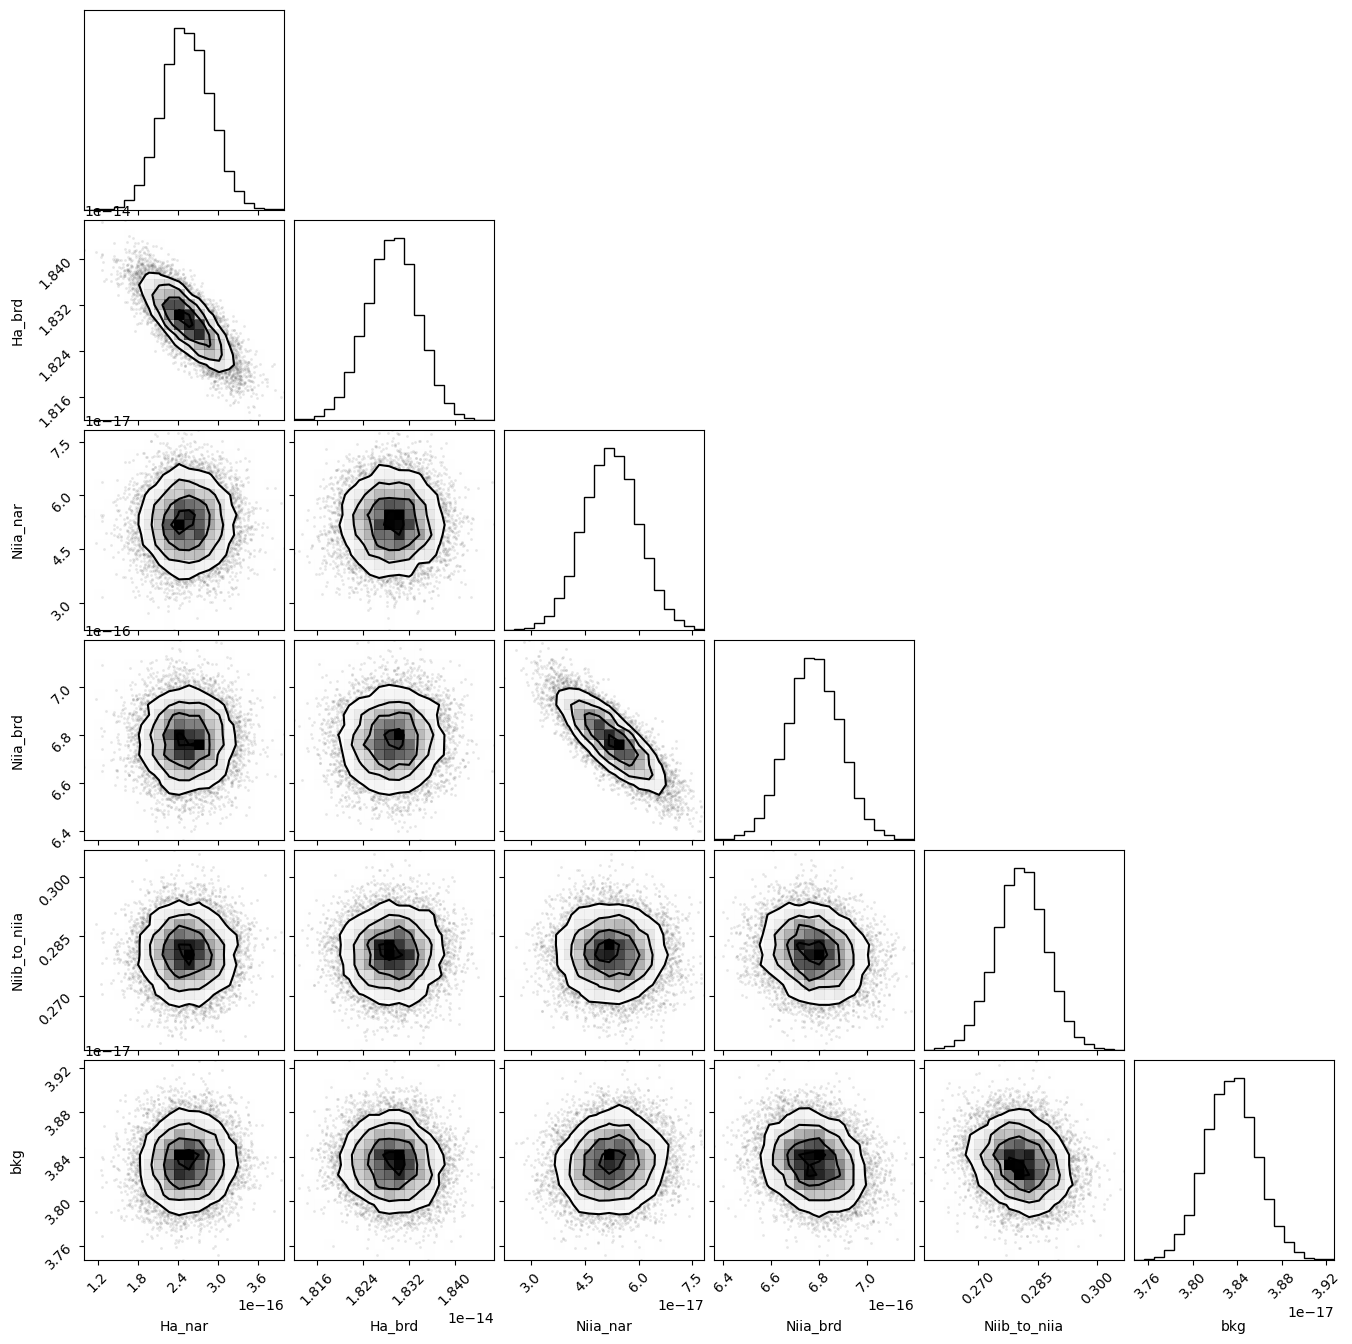

In [19]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [20]:
out_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19652131,,,0.19652130752330071,-inf,inf,False
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.77542545,,,0.7754254469354471,-inf,inf,False
sigma_brd,1.65421518,,,1.6542151798106632,-inf,inf,False
Ha_nar,2.5294e-16,3.5869e-17,(14.18%),2e-15,0.00000000,inf,True
Ha_brd,1.8292e-14,4.5388e-17,(0.25%),1.4e-14,0.00000000,inf,True
Niia_nar,5.2379e-17,7.6849e-18,(14.67%),1e-16,0.00000000,inf,True
Niia_brd,6.7776e-16,1.1060e-17,(1.63%),6e-16,0.00000000,inf,True
Niib_to_niia,0.28079247,0.00632523,(2.25%),0.3333333333333333,0.00000000,1.00000000,True
bkg,3.8347e-17,2.3124e-19,(0.60%),3e-17,-inf,inf,True


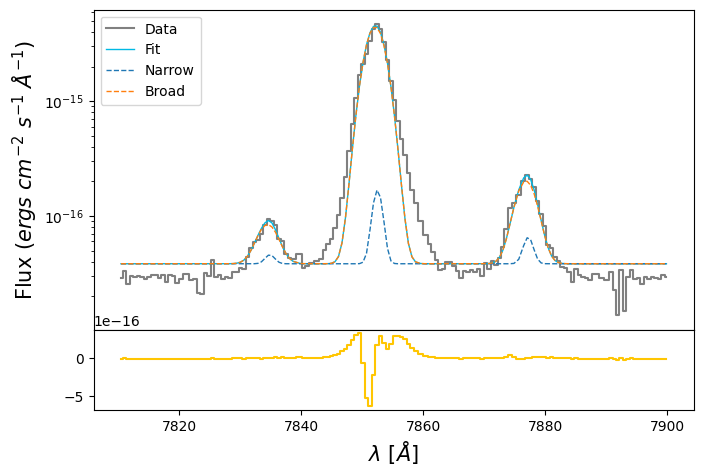

In [21]:
ha_nar_flux = out_ha_nii.flatchain.Ha_nar.mean()
ha_nar_std = out_ha_nii.flatchain.Ha_nar.std()

ha_brd_flux = out_ha_nii.flatchain.Ha_brd.mean()
ha_brd_std = out_ha_nii.flatchain.Ha_brd.std()

niia_nar_flux = out_ha_nii.flatchain.Niia_nar.mean()
niia_nar_std = out_ha_nii.flatchain.Niia_nar.std()

niia_brd_flux = out_ha_nii.flatchain.Niia_brd.mean()
niia_brd_std = out_ha_nii.flatchain.Niia_brd.std()

niib_nar_flux = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_nar_std = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).std()

niib_brd_flux = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_brd_std = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).std()

#z_ha_nii = out_ha_nii.flatchain.z_nar.mean()
#z_ha_nii_std = out_ha_nii.flatchain.z_nar.std()

bkg_ha_nii = out_ha_nii.flatchain.bkg.mean()
bkg_ha_nii_std = out_ha_nii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_nar_oiii_4959, upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_brd_oiii_4959, upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_nar_oiii_4959, upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_brd_oiii_4959, upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_nar_oiii_4959, upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_brd_oiii_4959, upy.nominal_values(sigma_brd_ha))

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
#ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
#ax.text(x=7008, y=1.5e-13, s=r'[NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584',
#       fontsize=15)
ax.legend(loc='upper left')

In [22]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

# HeI 7065

In [23]:
sigma_arc_7065 = (m * wave_cat['HeI7065']*(1 + z_BN[igal])) + n

sigma_nar_7065 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7065**2))
sigma_brd_7065 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7065**2))

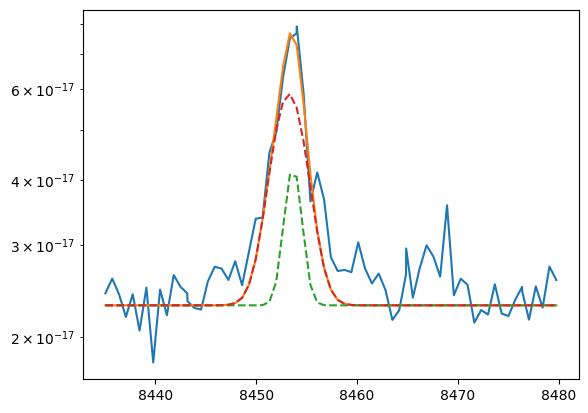

In [24]:
plt.plot(hei_7065.wavelength, hei_7065.flux)
bkg = 2.3e-17

hei7065_nar = gaussian(hei_7065.wavelength, 0.4e-16, wave_cat['HeI7065'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7065))
hei7065_brd = gaussian(hei_7065.wavelength, 1.5e-16, wave_cat['HeI7065'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7065))

hei7065 = hei7065_nar + hei7065_brd

plt.plot(hei_7065.wavelength, hei7065 + bkg)
plt.plot(hei_7065.wavelength, hei7065_nar + bkg, ls='--')
plt.plot(hei_7065.wavelength, hei7065_brd + bkg, ls='--')
plt.yscale('log')

In [25]:
params_7065 = Parameters()
params_7065.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_7065.add('z_ratio', value=z_ratio, vary=False)
params_7065.add('sigma_hei7065_nar', value=upy.nominal_values(sigma_nar_7065), vary=False)
params_7065.add('sigma_hei7065_brd', value=upy.nominal_values(sigma_brd_7065), vary=False)
params_7065.add('Hei7065_nar', value=0.4e-16, min=0.)
params_7065.add('Hei7065_brd', value=1.5e-16, min=0.)
params_7065.add('bkg', value=2.3e-17, min=0.)

def residual_hei7065(params_7065, x, data, uncertainty):
    
    z_nar = params_7065['z_nar']
    z_brd = params_7065['z_nar'] * params_7065['z_ratio']
    sigma_hei7065_nar = params_7065['sigma_hei7065_nar']
    sigma_hei7065_brd = params_7065['sigma_hei7065_brd']
    hei7065_nar_flux = params_7065['Hei7065_nar']
    hei7065_brd_flux = params_7065['Hei7065_brd']
    bkg = params_7065['bkg']
    
    x = hei_7065.wavelength
    model = gaussian(x, hei7065_nar_flux, wave_cat['HeI7065'], z_nar, sigma_hei7065_nar) + \
            gaussian(x, hei7065_brd_flux, wave_cat['HeI7065'], z_brd, sigma_hei7065_brd)
    return (model + bkg - hei_7065.flux) / hei_7065.noise

In [26]:
np.random.seed(2101)
out_hei7065 = minimize(residual_hei7065, params_7065, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 132.82it/s]


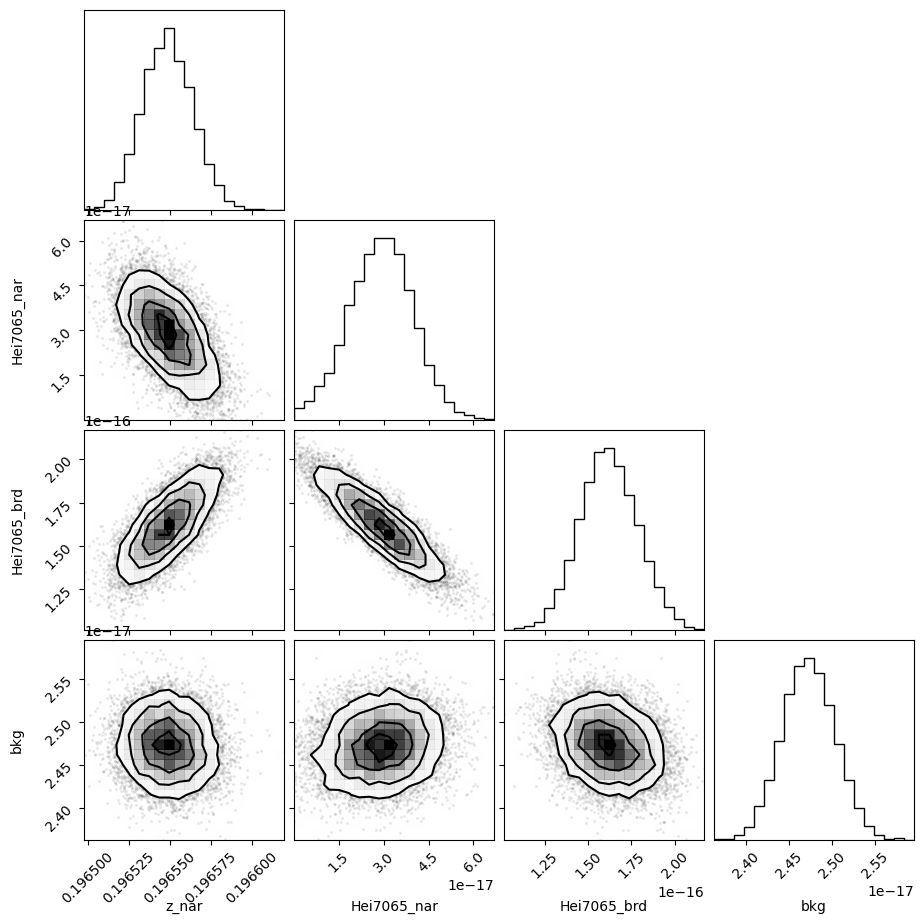

In [27]:
corner.corner(out_hei7065.flatchain, labels=out_hei7065.var_names);

In [28]:
out_hei7065.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19654877,1.5381e-05,(0.01%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_hei7065_nar,0.82520261,,,0.825202608000101,-inf,inf,False
sigma_hei7065_brd,1.67812472,,,1.6781247217090736,-inf,inf,False
Hei7065_nar,2.9357e-17,1.0649e-17,(36.27%),4e-17,0.00000000,inf,True
Hei7065_brd,1.6166e-16,1.6609e-17,(10.27%),1.5e-16,0.00000000,inf,True
bkg,2.4729e-17,3.0638e-19,(1.24%),2.3e-17,0.00000000,inf,True


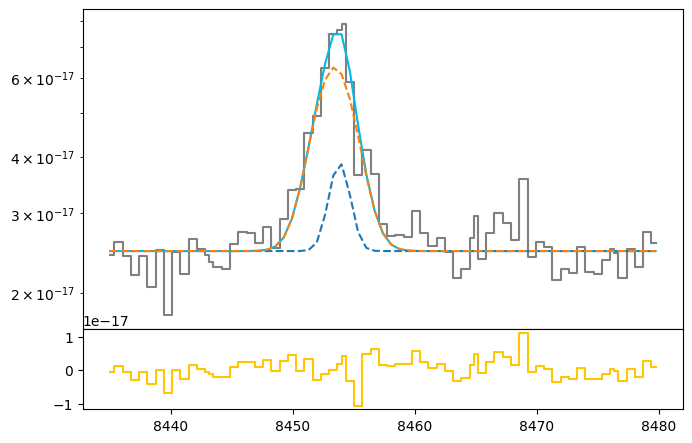

In [29]:
hei7065_nar_flux = out_hei7065.flatchain.Hei7065_nar.mean()
hei7065_nar_std = out_hei7065.flatchain.Hei7065_nar.std()

hei7065_brd_flux = out_hei7065.flatchain.Hei7065_brd.mean()
hei7065_brd_std = out_hei7065.flatchain.Hei7065_brd.std()

z_hei7065 = out_hei7065.flatchain.z_nar.mean()
z_hei7065_std = out_hei7065.flatchain.z_nar.std()

bkg_hei7065 = out_hei7065.flatchain.bkg.mean()
bkg_hei7065_std = out_hei7065.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_7065.wavelength, hei_7065.flux, color='gray', label='Data', where='mid')

hei7065_nar = gaussian(hei_7065.wavelength, hei7065_nar_flux, wave_cat['HeI7065'], z_hei7065, upy.nominal_values(sigma_nar_7065))
hei7065_brd = gaussian(hei_7065.wavelength, hei7065_brd_flux, wave_cat['HeI7065'], z_hei7065 * z_ratio, upy.nominal_values(sigma_brd_7065))

hei7065 = hei7065_nar + hei7065_brd

ax.plot(hei_7065.wavelength, bkg_hei7065 + hei7065, color=c[0])
ax.plot(hei_7065.wavelength, bkg_hei7065 + hei7065_nar, ls='--')
ax.plot(hei_7065.wavelength, bkg_hei7065 + hei7065_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_7065.wavelength, hei_7065.flux - bkg_hei7065 - hei7065, color=c[3], where='mid')

In [30]:
# EW
EW_hei7065_nar = ufloat(hei7065_nar_flux, hei7065_nar_std) / ufloat(bkg_hei7065, bkg_hei7065_std)
EW_hei7065_brd = ufloat(hei7065_brd_flux, hei7065_brd_std) / ufloat(bkg_hei7065, bkg_hei7065_std)
EW_hei7065 = (ufloat(hei7065_nar_flux, hei7065_nar_std) + ufloat(hei7065_brd_flux, hei7065_brd_std)) / ufloat(bkg_hei7065, bkg_hei7065_std)

# HeI 6678

In [31]:
sigma_arc_6678 = (m * wave_cat['HeI6678']*(1 + z_BN[igal])) + n

sigma_nar_6678 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6678**2))
sigma_brd_6678 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6678**2))

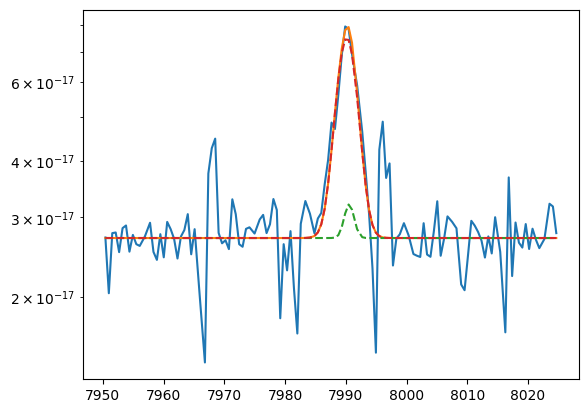

In [32]:
plt.plot(hei_6678.wavelength, hei_6678.flux)
bkg = 2.7e-17

hei6678_nar = gaussian(hei_6678.wavelength, 0.1e-16, wave_cat['HeI6678'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6678))
hei6678_brd = gaussian(hei_6678.wavelength, 2e-16, wave_cat['HeI6678'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6678))

hei6678 = hei6678_nar + hei6678_brd

plt.plot(hei_6678.wavelength, hei6678 + bkg)
plt.plot(hei_6678.wavelength, hei6678_nar + bkg, ls='--')
plt.plot(hei_6678.wavelength, hei6678_brd + bkg, ls='--')
plt.yscale('log')

In [33]:
params_6678 = Parameters()
params_6678.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_6678.add('z_ratio', value=z_ratio, vary=False)
params_6678.add('sigma_hei6678_nar', value=upy.nominal_values(sigma_nar_6678), vary=False)
params_6678.add('sigma_hei6678_brd', value=upy.nominal_values(sigma_brd_6678), vary=False)
params_6678.add('Hei6678_nar', value=0.1e-16, min=0.)
params_6678.add('Hei6678_brd', value=2.0e-16, min=0.)
params_6678.add('bkg', value=2.7e-17, min=0.)

def residual_hei6678(params_6678, x, data, uncertainty):
    
    z_nar = params_6678['z_nar']
    z_brd = params_6678['z_nar'] * params_6678['z_ratio']
    sigma_hei6678_nar = params_6678['sigma_hei6678_nar']
    sigma_hei6678_brd = params_6678['sigma_hei6678_brd']
    hei6678_nar_flux = params_6678['Hei6678_nar']
    hei6678_brd_flux = params_6678['Hei6678_brd']
    bkg = params_6678['bkg']
    
    x = hei_6678.wavelength
    model = gaussian(x, hei6678_nar_flux, wave_cat['HeI6678'], z_nar, sigma_hei6678_nar) + \
            gaussian(x, hei6678_brd_flux, wave_cat['HeI6678'], z_brd, sigma_hei6678_brd)
    return (model + bkg - hei_6678.flux) / hei_6678.noise

In [34]:
np.random.seed(2101)
out_hei6678 = minimize(residual_hei6678, params_6678, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 135.16it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [46.97145867 50.389346   43.99237565 43.88874296]


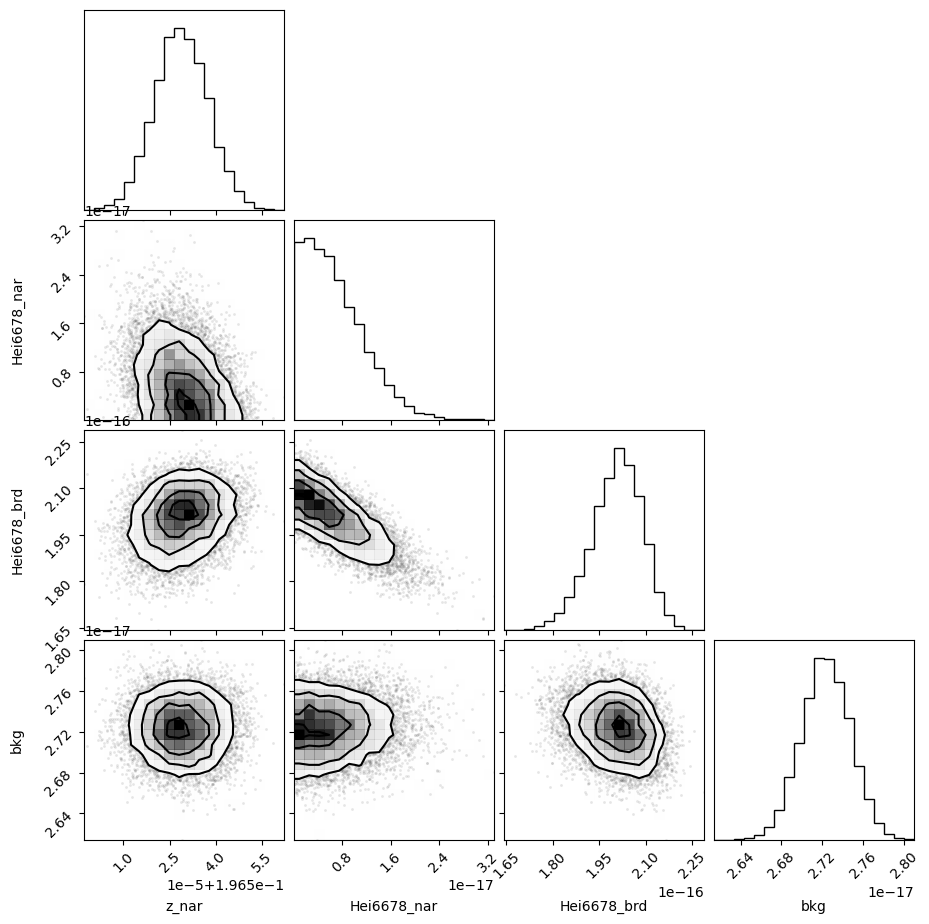

In [35]:
corner.corner(out_hei6678.flatchain, labels=out_hei6678.var_names);

In [36]:
out_hei6678.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19652873,8.5925e-06,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_hei6678_nar,0.78684029,,,0.7868402889112938,-inf,inf,False
sigma_hei6678_brd,1.65959660,,,1.6595966008687157,-inf,inf,False
Hei6678_nar,5.8990e-18,4.9792e-18,(84.41%),1e-17,0.00000000,inf,True
Hei6678_brd,2.0108e-16,8.0602e-18,(4.01%),2e-16,0.00000000,inf,True
bkg,2.7237e-17,2.3808e-19,(0.87%),2.7e-17,0.00000000,inf,True


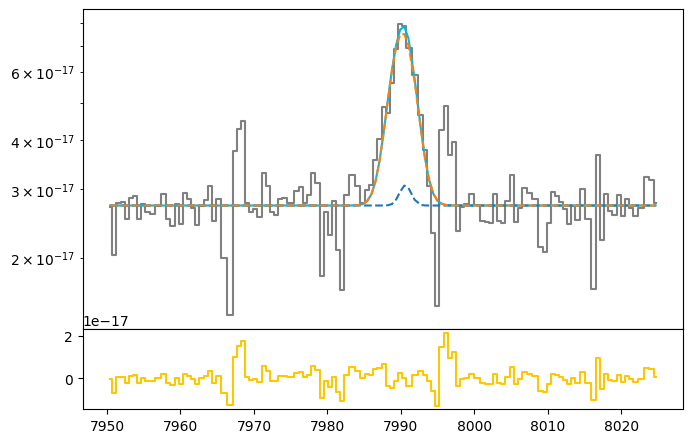

In [37]:
hei6678_nar_flux = out_hei6678.flatchain.Hei6678_nar.mean()
hei6678_nar_std = out_hei6678.flatchain.Hei6678_nar.std()

hei6678_brd_flux = out_hei6678.flatchain.Hei6678_brd.mean()
hei6678_brd_std = out_hei6678.flatchain.Hei6678_brd.std()

z_hei6678 = out_hei6678.flatchain.z_nar.mean()
z_hei6678_std = out_hei6678.flatchain.z_nar.std()

bkg_hei6678 = out_hei6678.flatchain.bkg.mean()
bkg_hei6678_std = out_hei6678.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_6678.wavelength, hei_6678.flux, color='gray', label='Data', where='mid')

hei6678_nar = gaussian(hei_6678.wavelength, hei6678_nar_flux, wave_cat['HeI6678'], z_hei6678, upy.nominal_values(sigma_nar_6678))
hei6678_brd = gaussian(hei_6678.wavelength, hei6678_brd_flux, wave_cat['HeI6678'], z_hei6678 * z_ratio, upy.nominal_values(sigma_brd_6678))

hei6678 = hei6678_nar + hei6678_brd

ax.plot(hei_6678.wavelength, bkg_hei6678 + hei6678, color=c[0])
ax.plot(hei_6678.wavelength, bkg_hei6678 + hei6678_nar, ls='--')
ax.plot(hei_6678.wavelength, bkg_hei6678 + hei6678_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_6678.wavelength, hei_6678.flux - bkg_hei6678 - hei6678, color=c[3], where='mid')

In [38]:
# EW
EW_hei6678_nar = ufloat(hei6678_nar_flux, hei6678_nar_std) / ufloat(bkg_hei6678, bkg_hei6678_std)
EW_hei6678_brd = ufloat(hei6678_brd_flux, hei6678_brd_std) / ufloat(bkg_hei6678, bkg_hei6678_std)
EW_hei6678 = (ufloat(hei6678_nar_flux, hei6678_nar_std) + ufloat(hei6678_brd_flux, hei6678_brd_std)) / ufloat(bkg_hei6678, bkg_hei6678_std)

# HeI 5875

In [39]:
sigma_arc_5875 = (m * wave_cat['HeI5875']*(1 + z_BN[igal])) + n

sigma_nar_5875 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5875**2))
sigma_brd_5875 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5875**2))

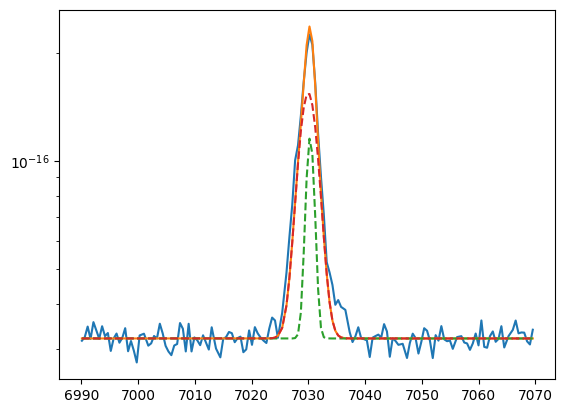

In [40]:
plt.plot(hei_5875.wavelength, hei_5875.flux)
bkg = 3.2e-17

hei5875_nar = gaussian(hei_5875.wavelength, 1.5e-16, wave_cat['HeI5875'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5875))
hei5875_brd = gaussian(hei_5875.wavelength, 5e-16, wave_cat['HeI5875'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5875))

hei5875 = hei5875_nar + hei5875_brd

plt.plot(hei_5875.wavelength, hei5875 + bkg)
plt.plot(hei_5875.wavelength, hei5875_nar + bkg, ls='--')
plt.plot(hei_5875.wavelength, hei5875_brd + bkg, ls='--')
plt.yscale('log')

In [41]:
params_5875 = Parameters()
params_5875.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_5875.add('z_ratio', value=z_ratio, vary=False)
params_5875.add('sigma_hei5875_nar', value=upy.nominal_values(sigma_nar_5875), vary=False)
params_5875.add('sigma_hei5875_brd', value=upy.nominal_values(sigma_brd_5875), vary=False)
params_5875.add('Hei5875_nar', value=1.3e-16, min=0.)
params_5875.add('Hei5875_brd', value=5e-16, min=0.)
params_5875.add('bkg', value=3.2e-17, min=0.)

def residual_hei5875(params_5875, x, data, uncertainty):
    
    z_nar = params_5875['z_nar']
    z_brd = params_5875['z_nar'] * params_5875['z_ratio']
    sigma_hei5875_nar = params_5875['sigma_hei5875_nar']
    sigma_hei5875_brd = params_5875['sigma_hei5875_brd']
    hei5875_nar_flux = params_5875['Hei5875_nar']
    hei5875_brd_flux = params_5875['Hei5875_brd']
    bkg = params_5875['bkg']
    
    x = hei_5875.wavelength
    model = gaussian(x, hei5875_nar_flux, wave_cat['HeI5875'], z_nar, sigma_hei5875_nar) + \
            gaussian(x, hei5875_brd_flux, wave_cat['HeI5875'], z_brd, sigma_hei5875_brd)
    return (model + bkg - hei_5875.flux) / hei_5875.noise

In [42]:
np.random.seed(2101)
out_hei5875 = minimize(residual_hei5875, params_5875, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 121.40it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [40.64992403 77.55678547 75.35122969 42.88190572]


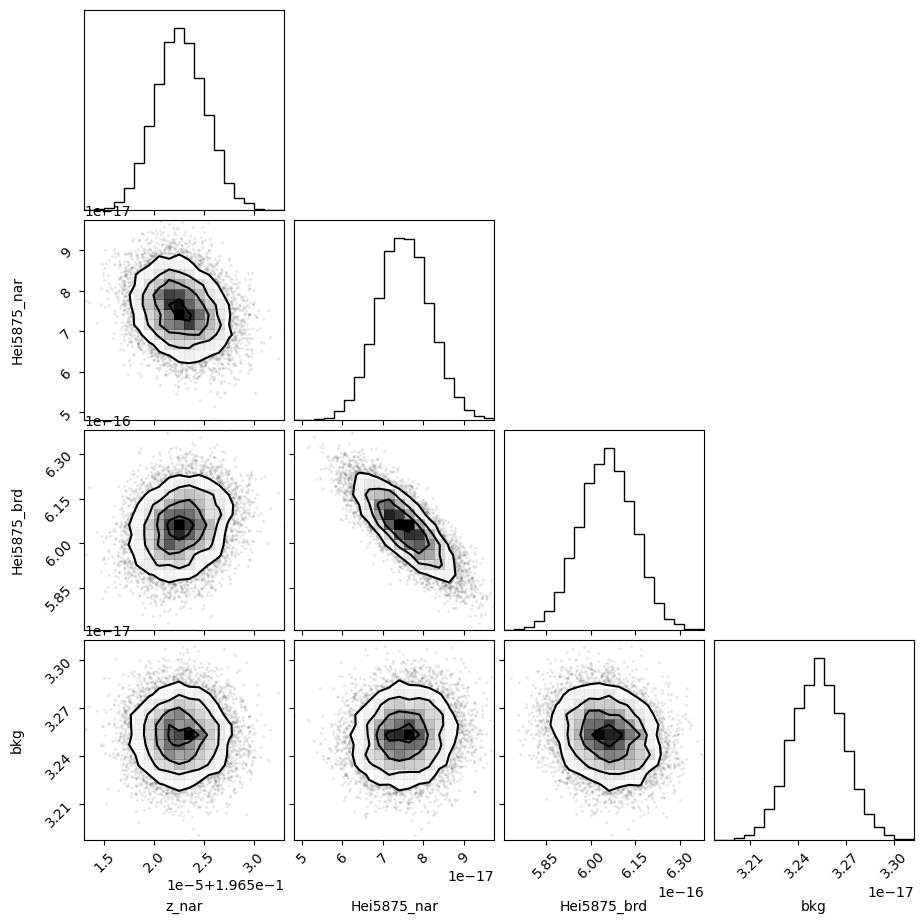

In [43]:
corner.corner(out_hei5875.flatchain, labels=out_hei5875.var_names);

In [44]:
out_hei5875.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19652265,2.5291e-06,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_hei5875_nar,0.70764664,,,0.7076466399078075,-inf,inf,False
sigma_hei5875_brd,1.62354766,,,1.6235476600130336,-inf,inf,False
Hei5875_nar,7.5235e-17,6.4289e-18,(8.55%),1.3e-16,0.00000000,inf,True
Hei5875_brd,6.0544e-16,9.1619e-18,(1.51%),5e-16,0.00000000,inf,True
bkg,3.2526e-17,1.6395e-19,(0.50%),3.2e-17,0.00000000,inf,True


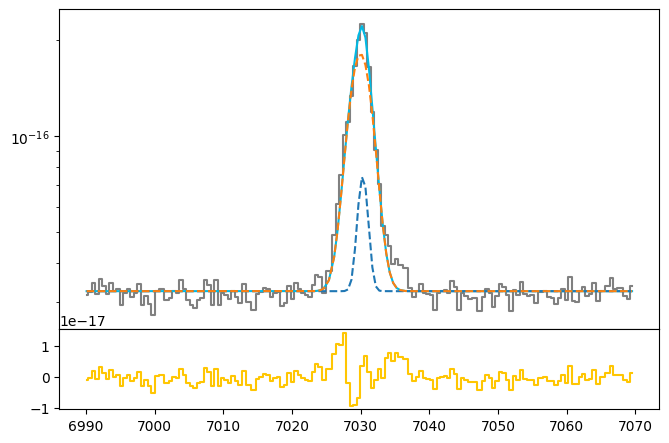

In [45]:
hei5875_nar_flux = out_hei5875.flatchain.Hei5875_nar.mean()
hei5875_nar_std = out_hei5875.flatchain.Hei5875_nar.std()

hei5875_brd_flux = out_hei5875.flatchain.Hei5875_brd.mean()
hei5875_brd_std = out_hei5875.flatchain.Hei5875_brd.std()

z_hei5875 = out_hei5875.flatchain.z_nar.mean()
z_hei5875_std = out_hei5875.flatchain.z_nar.std()

bkg_hei5875 = out_hei5875.flatchain.bkg.mean()
bkg_hei5875_std = out_hei5875.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_5875.wavelength, hei_5875.flux, color='gray', label='Data', where='mid')

hei5875_nar = gaussian(hei_5875.wavelength, hei5875_nar_flux, wave_cat['HeI5875'], z_hei5875, upy.nominal_values(sigma_nar_5875))
hei5875_brd = gaussian(hei_5875.wavelength, hei5875_brd_flux, wave_cat['HeI5875'], z_hei5875 * z_ratio, upy.nominal_values(sigma_brd_5875))

hei5875 = hei5875_nar + hei5875_brd

ax.plot(hei_5875.wavelength, bkg_hei5875 + hei5875, color=c[0])
ax.plot(hei_5875.wavelength, bkg_hei5875 + hei5875_nar, ls='--')
ax.plot(hei_5875.wavelength, bkg_hei5875 + hei5875_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_5875.wavelength, hei_5875.flux - bkg_hei5875 - hei5875, color=c[3], where='mid')

In [46]:
# EW
EW_hei5875_nar = ufloat(hei5875_nar_flux, hei5875_nar_std) / ufloat(bkg_hei5875, bkg_hei5875_std)
EW_hei5875_brd = ufloat(hei5875_brd_flux, hei5875_brd_std) / ufloat(bkg_hei5875, bkg_hei5875_std)
EW_hei5875 = (ufloat(hei5875_nar_flux, hei5875_nar_std) + ufloat(hei5875_brd_flux, hei5875_brd_std)) / ufloat(bkg_hei5875, bkg_hei5875_std)

# HeI 4471

In [47]:
sigma_arc_4471 = (m * wave_cat['HeI4471']*(1 + z_BN[igal])) + n

sigma_nar_4471 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4471**2))
sigma_brd_4471 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4471**2))

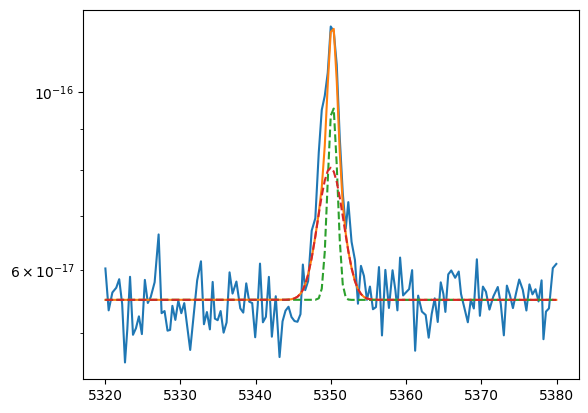

In [48]:
plt.plot(hei_4471.wavelength, hei_4471.flux)
bkg = 5.5e-17

hei4471_nar = gaussian(hei_4471.wavelength, 0.6e-16, wave_cat['HeI4471'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4471))
hei4471_brd = gaussian(hei_4471.wavelength, 1e-16, wave_cat['HeI4471'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4471))

hei4471 = hei4471_nar + hei4471_brd

plt.plot(hei_4471.wavelength, hei4471 + bkg)
plt.plot(hei_4471.wavelength, hei4471_nar + bkg, ls='--')
plt.plot(hei_4471.wavelength, hei4471_brd + bkg, ls='--')
plt.yscale('log')

In [49]:
params_4471 = Parameters()
params_4471.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_4471.add('z_ratio', value=z_ratio, vary=False)
params_4471.add('sigma_hei4471_nar', value=upy.nominal_values(sigma_nar_4471), vary=False)
params_4471.add('sigma_hei4471_brd', value=upy.nominal_values(sigma_brd_4471), vary=False)
params_4471.add('Hei4471_nar', value=0.6e-16, min=0.)
params_4471.add('Hei4471_brd', value=1.0e-16, min=0.)
params_4471.add('bkg', value=5.5e-17, min=0.)

def residual_hei4471(params_4471, x, data, uncertainty):
    
    z_nar = params_4471['z_nar']
    z_brd = params_4471['z_nar'] * params_4471['z_ratio']
    sigma_hei4471_nar = params_4471['sigma_hei4471_nar']
    sigma_hei4471_brd = params_4471['sigma_hei4471_brd']
    hei4471_nar_flux = params_4471['Hei4471_nar']
    hei4471_brd_flux = params_4471['Hei4471_brd']
    bkg = params_4471['bkg']
    
    x = hei_4471.wavelength
    model = gaussian(x, hei4471_nar_flux, wave_cat['HeI4471'], z_nar, sigma_hei4471_nar) + \
            gaussian(x, hei4471_brd_flux, wave_cat['HeI4471'], z_brd, sigma_hei4471_brd)
    return (model + bkg - hei_4471.flux) / hei_4471.noise

In [50]:
np.random.seed(2101)
out_hei4471 = minimize(residual_hei4471, params_4471, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 123.21it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [36.76734843 66.18191057 72.85471266 41.1716029 ]


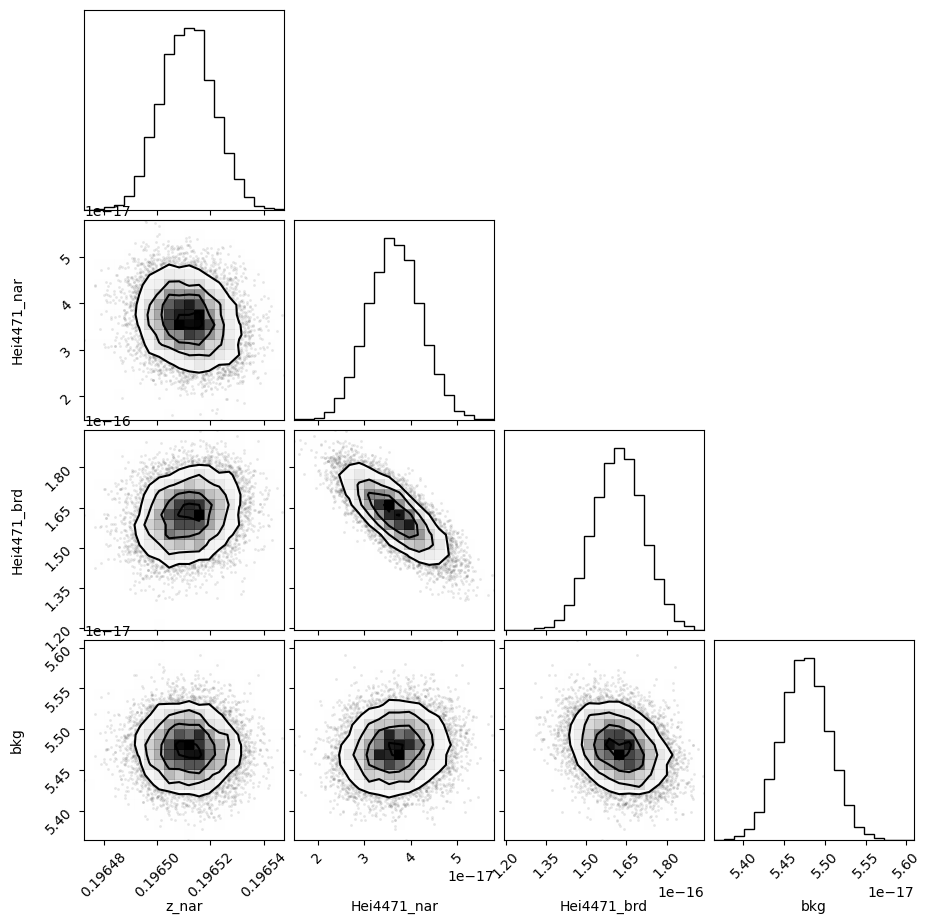

In [51]:
corner.corner(out_hei4471.flatchain, labels=out_hei4471.var_names);

In [52]:
out_hei4471.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19651138,9.9337e-06,(0.01%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_hei4471_nar,0.57073577,,,0.570735768869991,-inf,inf,False
sigma_hei4471_brd,1.56872004,,,1.568720037236921,-inf,inf,False
Hei4471_nar,3.6564e-17,5.6917e-18,(15.57%),6e-17,0.00000000,inf,True
Hei4471_brd,1.6229e-16,9.3177e-18,(5.74%),1e-16,0.00000000,inf,True
bkg,5.4759e-17,2.8969e-19,(0.53%),5.5e-17,0.00000000,inf,True


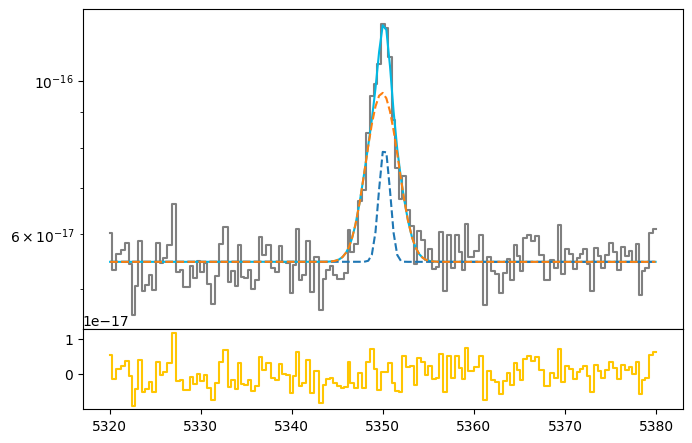

In [53]:
hei4471_nar_flux = out_hei4471.flatchain.Hei4471_nar.mean()
hei4471_nar_std = out_hei4471.flatchain.Hei4471_nar.std()

hei4471_brd_flux = out_hei4471.flatchain.Hei4471_brd.mean()
hei4471_brd_std = out_hei4471.flatchain.Hei4471_brd.std()

z_hei4471 = out_hei4471.flatchain.z_nar.mean()
z_hei4471_std = out_hei4471.flatchain.z_nar.std()

bkg_hei4471 = out_hei4471.flatchain.bkg.mean()
bkg_hei4471_std = out_hei4471.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hei_4471.wavelength, hei_4471.flux, color='gray', label='Data', where='mid')

hei4471_nar = gaussian(hei_4471.wavelength, hei4471_nar_flux, wave_cat['HeI4471'], z_hei4471, upy.nominal_values(sigma_nar_4471))
hei4471_brd = gaussian(hei_4471.wavelength, hei4471_brd_flux, wave_cat['HeI4471'], z_hei4471 * z_ratio, upy.nominal_values(sigma_brd_4471))

hei4471 = hei4471_nar + hei4471_brd

ax.plot(hei_4471.wavelength, bkg_hei4471 + hei4471, color=c[0])
ax.plot(hei_4471.wavelength, bkg_hei4471 + hei4471_nar, ls='--')
ax.plot(hei_4471.wavelength, bkg_hei4471 + hei4471_brd, ls='--')
ax.set_yscale('log')
ax1.step(hei_4471.wavelength, hei_4471.flux - bkg_hei4471 - hei4471, color=c[3], where='mid')

In [54]:
# EW
EW_hei4471_nar = ufloat(hei4471_nar_flux, hei4471_nar_std) / ufloat(bkg_hei4471, bkg_hei4471_std)
EW_hei4471_brd = ufloat(hei4471_brd_flux, hei4471_brd_std) / ufloat(bkg_hei4471, bkg_hei4471_std)
EW_hei4471 = (ufloat(hei4471_nar_flux, hei4471_nar_std) + ufloat(hei4471_brd_flux, hei4471_brd_std)) / ufloat(bkg_hei4471, bkg_hei4471_std)

# [OII]7319 + [OII]7330

In [55]:
sigma_arc_7330 = (m * wave_cat['[OII]7330']*(1 + z_BN[igal])) + n

sigma_nar_7330 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7330**2))
sigma_brd_7330 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7330**2))

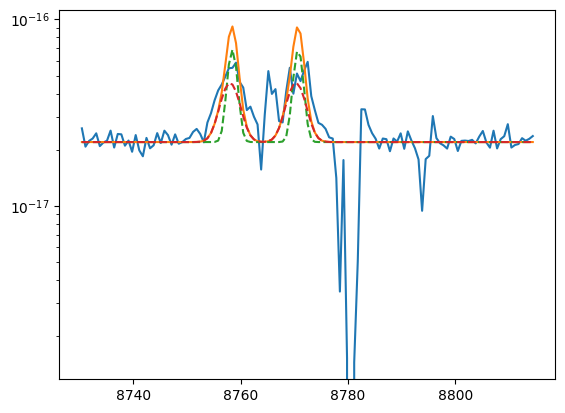

In [56]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 1e-16, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiia_brd = gaussian(oii_7320.wavelength, 1e-16, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiib_nar = gaussian(oii_7320.wavelength, 1e-16, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiib_brd = gaussian(oii_7320.wavelength, 1e-16, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 2.2e-17

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [57]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('Oiia_nar', value=1.0e-16, min=0.)
params_oii_7320.add('Oiia_brd', value=1.0e-16, min=0.)
params_oii_7320.add('Oiib_nar', value=1.0e-16, min=0.)
params_oii_7320.add('Oiib_brd', value=1.0e-16, min=0.)
params_oii_7320.add('bkg', value=2.2e-17, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [58]:
np.random.seed(2101)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 114.91it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 75.62802803 161.5032652  127.86618095 107.65305917 124.46316467
  53.09394623]


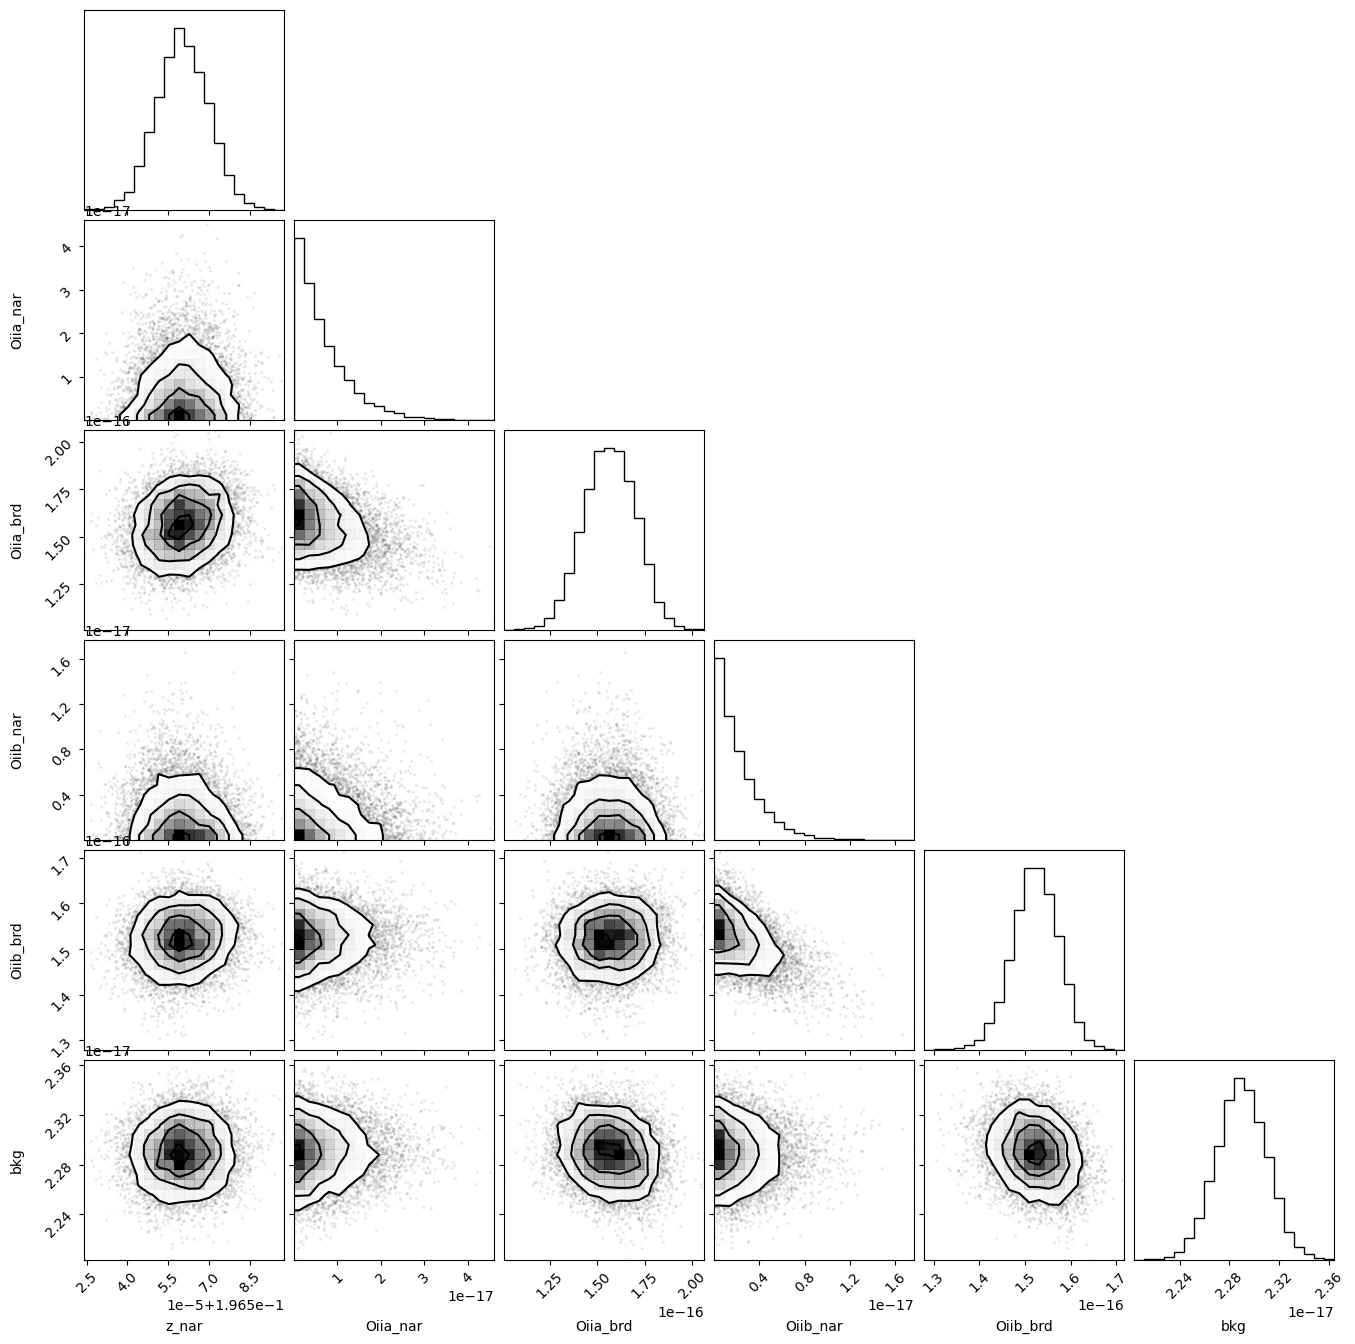

In [59]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

In [60]:
out_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19656010,9.4817e-06,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.85152153,,,0.851521528344857,-inf,inf,False
sigma_brd,1.69122209,,,1.691222087898496,-inf,inf,False
Oiia_nar,4.9425e-18,5.5739e-18,(112.78%),1e-16,0.00000000,inf,True
Oiia_brd,1.5664e-16,1.3693e-17,(8.74%),1e-16,0.00000000,inf,True
Oiib_nar,1.5851e-18,1.8124e-18,(114.34%),1e-16,0.00000000,inf,True
Oiib_brd,1.5231e-16,4.9914e-18,(3.28%),1e-16,0.00000000,inf,True
bkg,2.2898e-17,2.0010e-19,(0.87%),2.2e-17,0.00000000,inf,True


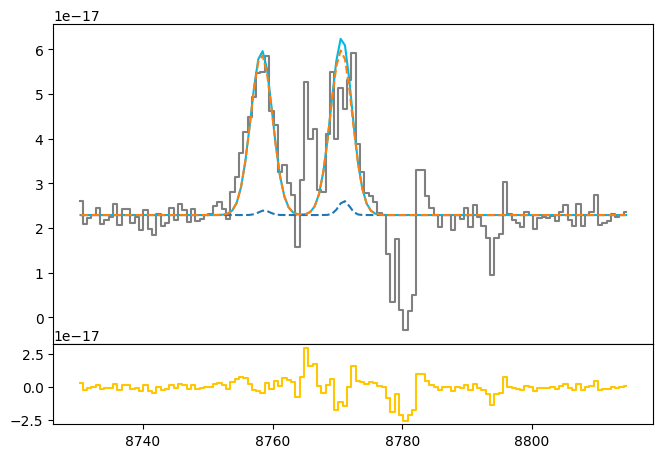

In [61]:
oiia_nar_flux = out_oii_7320.flatchain.Oiia_nar.mean()
oiia_nar_std = out_oii_7320.flatchain.Oiia_nar.std()

oiia_brd_flux = out_oii_7320.flatchain.Oiia_brd.mean()
oiia_brd_std = out_oii_7320.flatchain.Oiia_brd.std()

oiib_nar_flux = out_oii_7320.flatchain.Oiib_nar.mean()
oiib_nar_std = out_oii_7320.flatchain.Oiib_nar.std()

oiib_brd_flux = out_oii_7320.flatchain.Oiib_brd.mean()
oiib_brd_std = out_oii_7320.flatchain.Oiib_brd.std()

z_oii_7320 = out_oii_7320.flatchain.z_nar.mean()
z_oii_7320_std = out_oii_7320.flatchain.z_nar.std()

bkg_oii_7320 = out_oii_7320.flatchain.bkg.mean()
bkg_oii_7320_std = out_oii_7320.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, upy.nominal_values(sigma_nar_7330))
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, upy.nominal_values(sigma_nar_7330))

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')

In [62]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

# [SII]6716 + [SII]6730

In [63]:
sigma_arc_6730 = (m * wave_cat['[SII]6730']*(1 + z_BN[igal])) + n

sigma_nar_6730 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6730**2))
sigma_brd_6730 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6730**2))

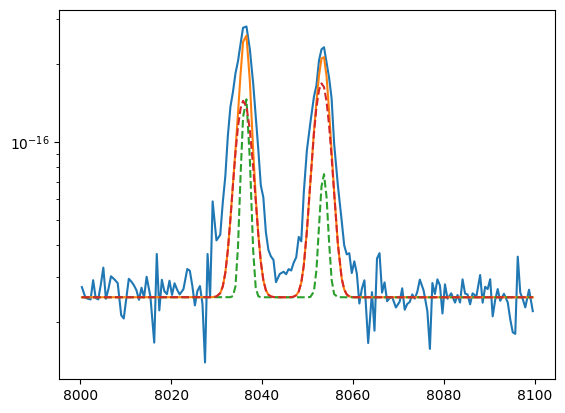

In [64]:
plt.plot(sii.wavelength, sii.flux)
bkg = 2.5e-17

siia_nar = gaussian(sii.wavelength, 1e-16, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siia_brd = gaussian(sii.wavelength, 6e-16, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siib_nar = gaussian(sii.wavelength, 2.5e-16, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siib_brd = gaussian(sii.wavelength, 5e-16, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib + bkg)
plt.plot(sii.wavelength, siia_nar + siib_nar + bkg, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd + bkg, ls='--')
plt.yscale('log')

In [65]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('Siia_nar', value=1.0e-16, min=0.)
params_sii.add('Siia_brd', value=6.0e-16, min=0.)
params_sii.add('Siib_nar', value=2.5e-16, min=0.)
params_sii.add('Siib_brd', value=5.0e-16, min=0.)
params_sii.add('bkg', value=2.5e-17, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_nar = params_sii['sigma_nar']
    sigma_brd = params_sii['sigma_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    bkg = params_sii['bkg']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_brd)
    model = model_siia + model_siib
    return (model + bkg - sii.flux) / sii.noise

In [66]:
np.random.seed(2101)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 108.47it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 34.71072769 166.97918847 126.54506109 136.62198704 138.26697838
  24.33897581]


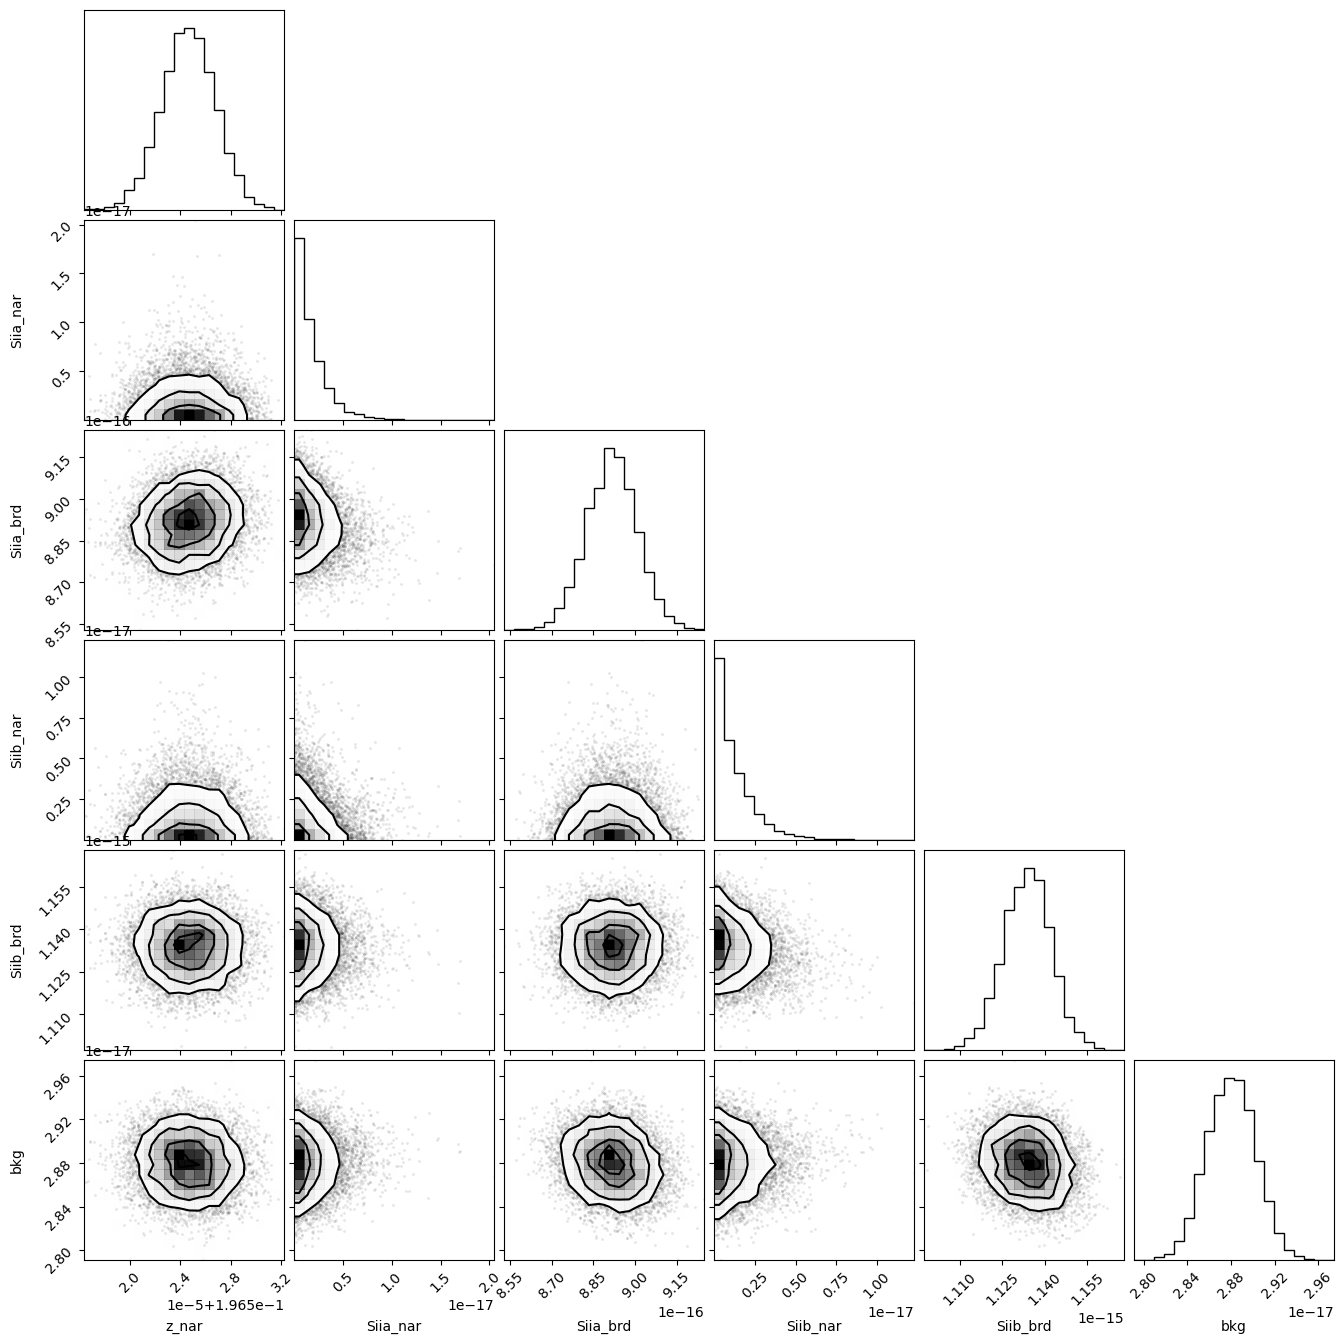

In [67]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);

In [68]:
out_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19652464,2.1246e-06,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.79205443,,,0.7920544260105472,-inf,inf,False
sigma_brd,1.66207504,,,1.6620750437702518,-inf,inf,False
Siia_nar,1.2188e-18,1.4322e-18,(117.52%),1e-16,0.00000000,inf,True
Siia_brd,8.9172e-16,9.0264e-18,(1.01%),6e-16,0.00000000,inf,True
Siib_nar,8.5503e-19,1.0658e-18,(124.65%),2.5e-16,0.00000000,inf,True
Siib_brd,1.1339e-15,8.2159e-18,(0.72%),5e-16,0.00000000,inf,True
bkg,2.8804e-17,2.2254e-19,(0.77%),2.5e-17,0.00000000,inf,True


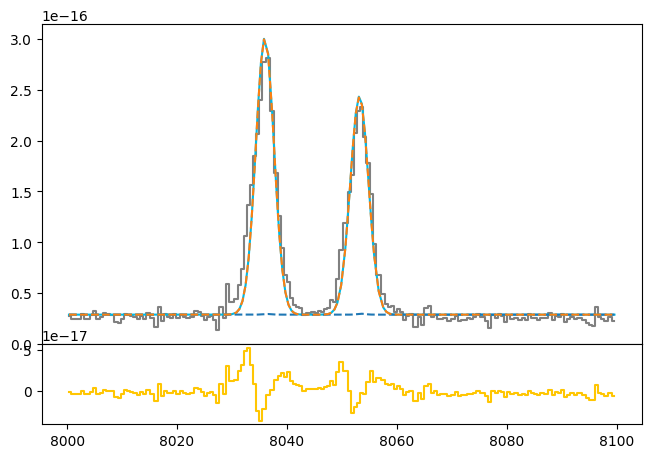

In [69]:
siia_nar_flux = out_sii.flatchain.Siia_nar.mean()
siia_nar_std = out_sii.flatchain.Siia_nar.std()

siia_brd_flux = out_sii.flatchain.Siia_brd.mean()
siia_brd_std = out_sii.flatchain.Siia_brd.std()

siib_nar_flux = out_sii.flatchain.Siib_nar.mean()
siib_nar_std = out_sii.flatchain.Siib_nar.std()

siib_brd_flux = out_sii.flatchain.Siib_brd.mean()
siib_brd_std = out_sii.flatchain.Siib_brd.std()

z_sii = out_sii.flatchain.z_nar.mean()
z_sii_std = out_sii.flatchain.z_nar.std()

bkg_sii = out_sii.flatchain.bkg.mean()
bkg_sii_std = out_sii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, upy.nominal_values(sigma_nar_6730))
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, upy.nominal_values(sigma_nar_6730))

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, bkg_sii + siia + siib, color=c[0])
ax.plot(sii.wavelength, bkg_sii + siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, bkg_sii + siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - bkg_sii - siia - siib, color=c[3], where='mid')

In [70]:
# EW
EW_SII_6730_nar = ufloat(siia_nar_flux, siia_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730_brd = ufloat(siia_brd_flux, siia_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730 = (ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

EW_SII_6716_nar = ufloat(siib_nar_flux, siib_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716_brd = ufloat(siib_brd_flux, siib_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716 = (ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

# [NII]5755

In [71]:
sigma_arc_5755 = (m * wave_cat['[NII]5755']*(1 + z_BN[igal])) + n

sigma_nar_5755 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5755**2))
sigma_brd_5755 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5755**2))

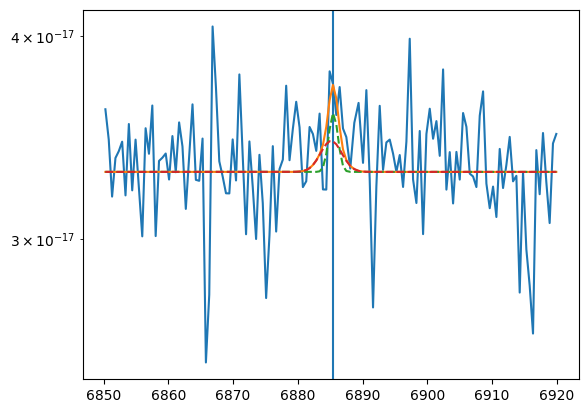

In [72]:
plt.plot(nii_5755.wavelength, nii_5755.flux)
bkg = 3.3e-17

niic_nar = gaussian(nii_5755.wavelength, 5.0e-18, wave_cat['[NII]5755'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5755))
niic_brd = gaussian(nii_5755.wavelength, 6.0e-18, wave_cat['[NII]5755'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5755))

niic = niic_nar + niic_brd

plt.axvline((1 + z_nar_oiii_4959) * wave_cat['[NII]5755'])
plt.plot(nii_5755.wavelength, niic + bkg)
plt.plot(nii_5755.wavelength, niic_nar + bkg, ls='--')
plt.plot(nii_5755.wavelength, niic_brd + bkg, ls='--')
plt.yscale('log')

In [73]:
params_nii = Parameters()
params_nii.add('z_nar', value=z_nar_oiii_4959, vary=False)
params_nii.add('z_ratio', value=z_ratio, vary=False)
params_nii.add('sigma_nar', value=upy.nominal_values(sigma_nar_5755), vary=False)
params_nii.add('sigma_brd', value=upy.nominal_values(sigma_brd_5755), vary=False)
params_nii.add('Niic_nar', value=5.0e-18, min=0.)
params_nii.add('Niic_brd', value=4.0e-18, min=0.)
params_nii.add('bkg', value=3.3e-17, min=0.)

def residual_nii(params_nii, x, data, uncertainty):
    
    z_nar = params_nii['z_nar']
    z_brd = params_nii['z_nar'] * params_nii['z_ratio']
    sigma_nar = params_nii['sigma_nar']
    sigma_brd = params_nii['sigma_brd']
    niic_nar_flux = params_nii['Niic_nar']
    niic_brd_flux = params_nii['Niic_brd']
    bkg = params_nii['bkg']
    
    x = nii_5755.wavelength
    model = gaussian(x, niic_nar_flux, wave_cat['[NII]5755'], z_nar, sigma_nar) + \
            gaussian(x, niic_brd_flux, wave_cat['[NII]5755'], z_brd, sigma_brd)
    return (model + bkg - nii_5755.flux) / nii_5755.noise

In [74]:
np.random.seed(2101)
out_nii = minimize(residual_nii, params_nii, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 142.23it/s]


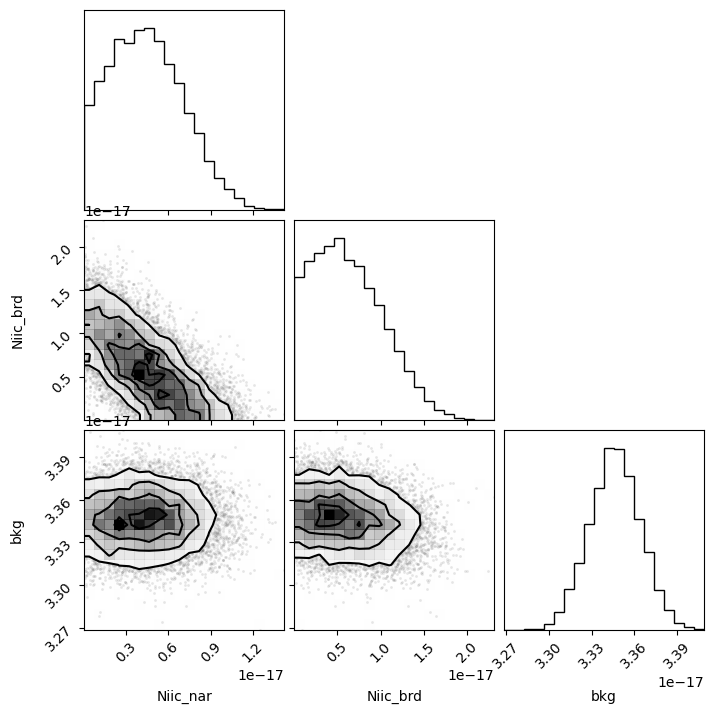

In [75]:
corner.corner(out_nii.flatchain, labels=out_nii.var_names);

In [76]:
out_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19652131,,,0.19652130752330071,-inf,inf,False
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.69575205,,,0.6957520545828415,-inf,inf,False
sigma_brd,1.61839864,,,1.6183986402667399,-inf,inf,False
Niic_nar,4.3192e-18,2.7202e-18,(62.98%),5e-18,0.00000000,inf,True
Niic_brd,5.8282e-18,4.2614e-18,(73.12%),4e-18,0.00000000,inf,True
bkg,3.3464e-17,1.7855e-19,(0.53%),3.3e-17,0.00000000,inf,True


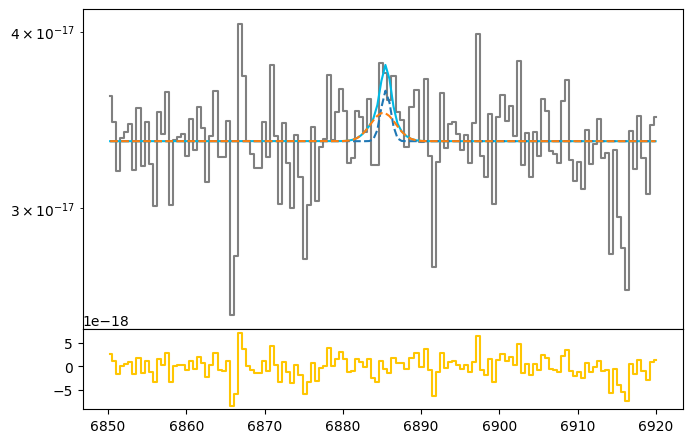

In [77]:
niic_nar_flux = out_nii.flatchain.Niic_nar.mean()
niic_nar_std = out_nii.flatchain.Niic_nar.std()

niic_brd_flux = out_nii.flatchain.Niic_brd.mean()
niic_brd_std = out_nii.flatchain.Niic_brd.std()

bkg_nii = out_nii.flatchain.bkg.mean()
bkg_nii_std = out_nii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(nii_5755.wavelength, nii_5755.flux, color='gray', label='Data', where='mid')

niic_nar = gaussian(nii_5755.wavelength, niic_nar_flux, wave_cat['[NII]5755'], z_nar_oiii_4959, upy.nominal_values(sigma_nar_oiii_4959))
niic_brd = gaussian(nii_5755.wavelength, niic_brd_flux, wave_cat['[NII]5755'], z_nar_oiii_4959 * z_ratio, upy.nominal_values(sigma_brd_oiii_4959))

niic = niic_nar + niic_brd

ax.plot(nii_5755.wavelength, bkg_nii + niic, color=c[0])
ax.plot(nii_5755.wavelength, bkg_nii + niic_nar, ls='--')
ax.plot(nii_5755.wavelength, bkg_nii + niic_brd, ls='--')
ax.set_yscale('log')
ax1.step(nii_5755.wavelength, nii_5755.flux - bkg_nii - niic, color=c[3], where='mid')

In [78]:
# EW
EW_NII_5755_nar = ufloat(niic_nar_flux, niic_nar_std) / ufloat(bkg_nii, bkg_nii_std)
EW_NII_5755_brd = ufloat(niic_brd_flux, niic_brd_std) / ufloat(bkg_nii, bkg_nii_std)
EW_NII_5755 = (ufloat(niic_nar_flux, niic_nar_std) + ufloat(niic_brd_flux, niic_brd_std)) / ufloat(bkg_nii, bkg_nii_std)

# H$\beta$

In [79]:
sigma_arc_hb = (m * wave_cat['Hb']*(1 + z_BN[igal])) + n

sigma_nar_hb = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hb**2))
sigma_brd_hb = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hb**2))

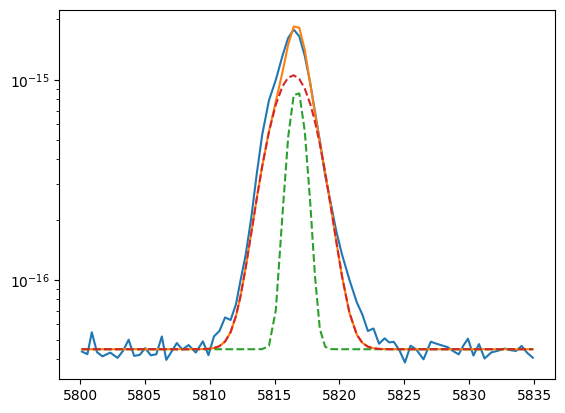

In [80]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 4.5e-17

hb_nar = gaussian(hbeta.wavelength, 1.3e-15, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, 4.0e-15, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb + bkg)
plt.plot(hbeta.wavelength, hb_nar + bkg, ls='--')
plt.plot(hbeta.wavelength, hb_brd + bkg, ls='--')
plt.yscale('log')

In [81]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_nar', value=upy.nominal_values(sigma_nar_hb), vary=False)
params_hb.add('sigma_brd', value=upy.nominal_values(sigma_brd_hb), vary=False)
params_hb.add('Hb_nar', value=1.3e-15, min=0.)
params_hb.add('Hb_brd', value=4.0e-15, min=0.)
params_hb.add('bkg', value=4.5e-17, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_nar = params_hb['sigma_nar']
    sigma_brd = params_hb['sigma_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    bkg = params_hb['bkg']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_brd)
    return (model + bkg - hbeta.flux) / hbeta.noise

In [82]:
np.random.seed(2101)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 129.86it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [37.3353829  95.03938661 76.7378495  54.2670494 ]


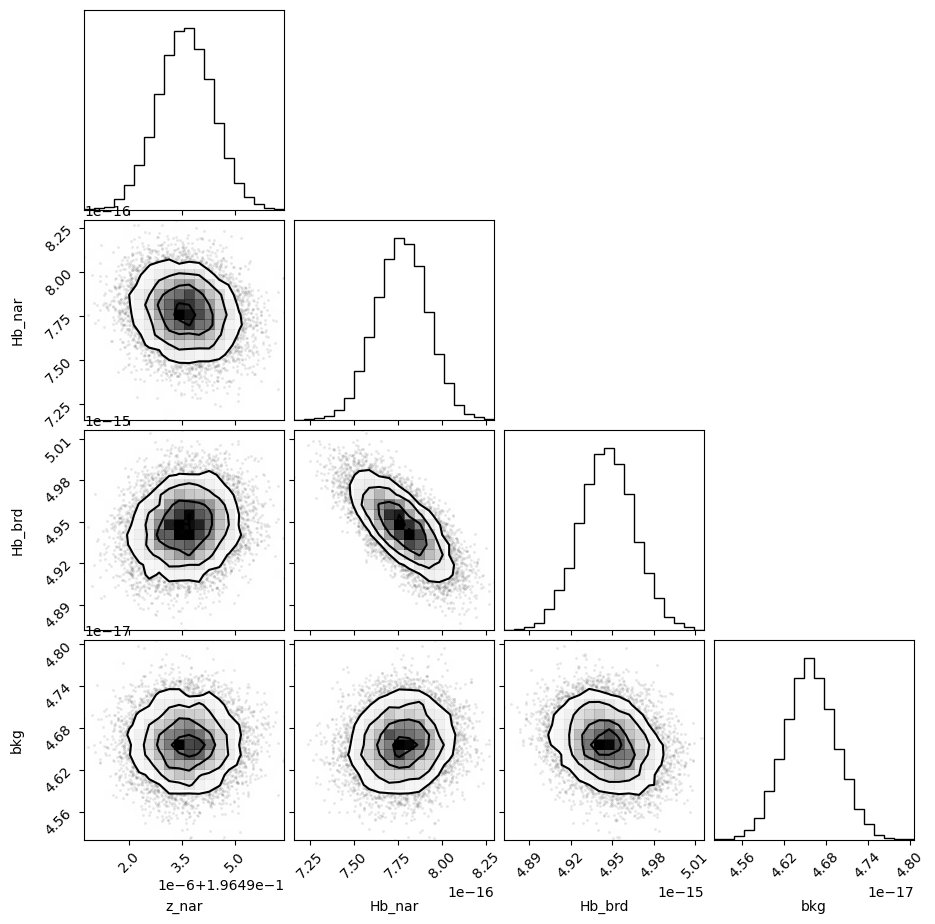

In [83]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

In [84]:
out_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19649360,7.7530e-07,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.60847803,,,0.608478025181437,-inf,inf,False
sigma_brd,1.58284198,,,1.5828419834240208,-inf,inf,False
Hb_nar,7.7741e-16,1.4525e-17,(1.87%),1.3e-15,0.00000000,inf,True
Hb_brd,4.9467e-15,1.9407e-17,(0.39%),4e-15,0.00000000,inf,True
bkg,4.6581e-17,3.6719e-19,(0.79%),4.5e-17,0.00000000,inf,True


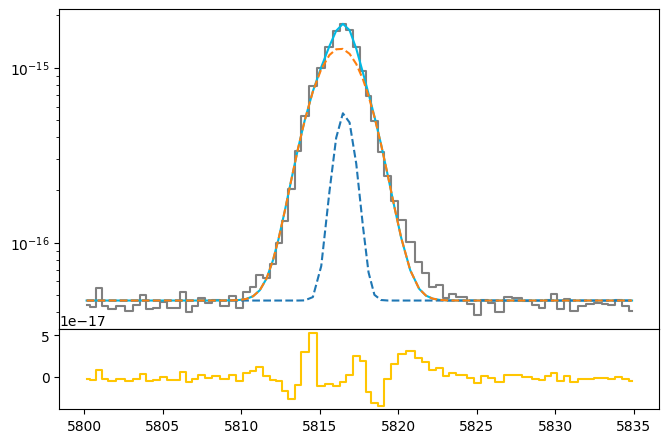

In [85]:
hb_nar_flux = out_hb.flatchain.Hb_nar.mean()
hb_nar_std = out_hb.flatchain.Hb_nar.std()

hb_brd_flux = out_hb.flatchain.Hb_brd.mean()
hb_brd_std = out_hb.flatchain.Hb_brd.std()

z_hb = out_hb.flatchain.z_nar.mean()
z_hb_std = out_hb.flatchain.z_nar.std()

bkg_hb = out_hb.flatchain.bkg.mean()
bkg_hb_std = out_hb.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, bkg_hb + hb, color=c[0])
ax.plot(hbeta.wavelength, bkg_hb + hb_nar, ls='--')
ax.plot(hbeta.wavelength, bkg_hb + hb_brd, ls='--')
ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - bkg_hb - hb, color=c[3], where='mid')

In [86]:
# EW
EW_Hb_nar = ufloat(hb_nar_flux, hb_nar_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb_brd = ufloat(hb_brd_flux, hb_brd_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb = (ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / ufloat(bkg_hb, bkg_hb_std)

# HeII 4686

In [87]:
sigma_arc_4685 = (m * wave_cat['HeII4685']*(1 + z_BN[igal])) + n

sigma_nar_4685 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4685**2))
sigma_brd_4685 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4685**2))

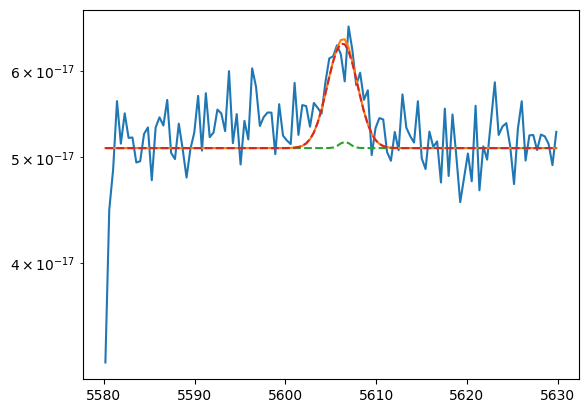

In [88]:
plt.plot(heii_4686.wavelength, heii_4686.flux)
bkg = 5.1e-17

heii4685_nar = gaussian(heii_4686.wavelength, 0.1e-17, wave_cat['HeII4685'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4685))
heii4685_brd = gaussian(heii_4686.wavelength, 5e-17, wave_cat['HeII4685'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4685))

heii4685 = heii4685_nar + heii4685_brd

plt.plot(heii_4686.wavelength, heii4685 + bkg)
plt.plot(heii_4686.wavelength, heii4685_nar + bkg, ls='--')
plt.plot(heii_4686.wavelength, heii4685_brd + bkg, ls='--')
plt.yscale('log')

In [89]:
params_4685 = Parameters()
params_4685.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_4685.add('z_ratio', value=z_ratio, vary=False)
params_4685.add('sigma_heii4685_nar', value=upy.nominal_values(sigma_nar_4685), vary=False)
params_4685.add('sigma_heii4685_brd', value=upy.nominal_values(sigma_brd_4685), vary=False)
params_4685.add('Heii4685_nar', value=0.1e-17, min=0.)
params_4685.add('Heii4685_brd', value=5.0e-17, min=0.)
params_4685.add('bkg', value=5e-17, min=0.)

def residual_heii4685(params_4685, x, data, uncertainty):
    
    z_nar = params_4685['z_nar']
    z_brd = params_4685['z_nar'] * params_4685['z_ratio']
    sigma_heii4685_nar = params_4685['sigma_heii4685_nar']
    sigma_heii4685_brd = params_4685['sigma_heii4685_brd']
    heii4685_nar_flux = params_4685['Heii4685_nar']
    heii4685_brd_flux = params_4685['Heii4685_brd']
    bkg = params_4685['bkg']
    
    x = heii_4686.wavelength
    model = gaussian(x, heii4685_nar_flux, wave_cat['HeII4685'], z_nar, sigma_heii4685_nar) + \
            gaussian(x, heii4685_brd_flux, wave_cat['HeII4685'], z_brd, sigma_heii4685_brd)
    return (model + bkg - heii_4686.flux) / heii_4686.noise

In [90]:
np.random.seed(2101)
out_heii4685 = minimize(residual_heii4685, params_4685, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 139.14it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [45.37806652 50.48781613 45.76774752 46.57344373]


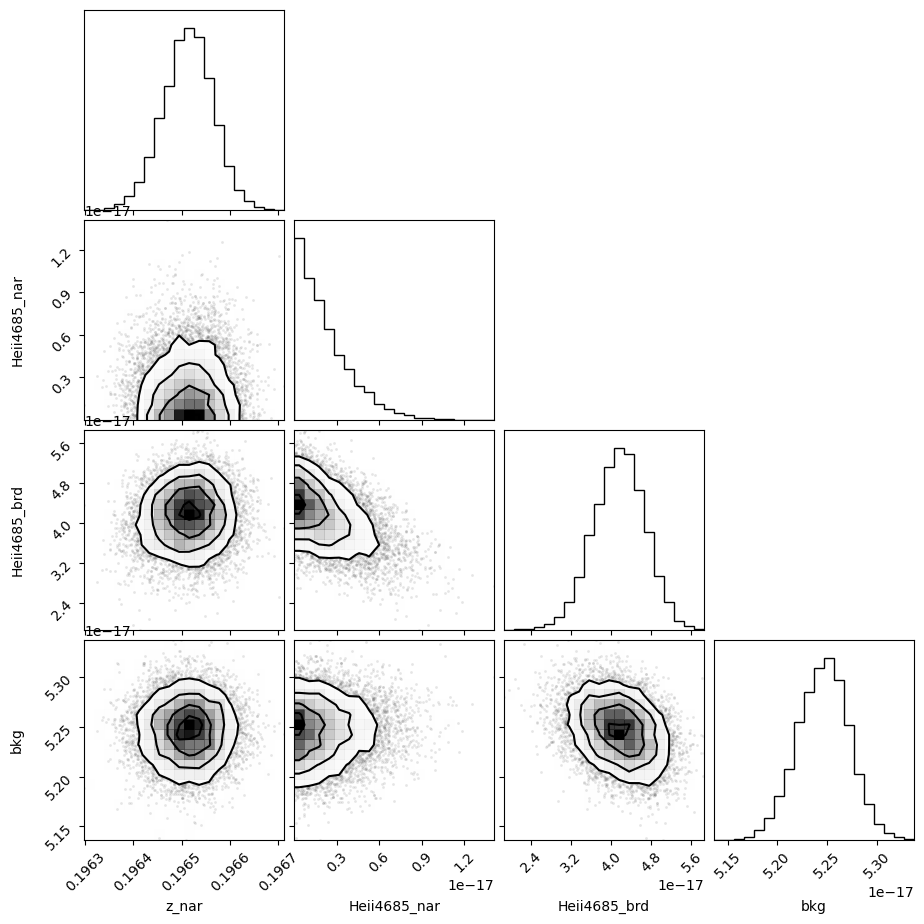

In [91]:
corner.corner(out_heii4685.flatchain, labels=out_heii4685.var_names);

In [92]:
out_heii4685.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19651421,5.1096e-05,(0.03%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_heii4685_nar,0.59144384,,,0.5914438362491931,-inf,inf,False
sigma_heii4685_brd,1.57637212,,,1.5763721162207067,-inf,inf,False
Heii4685_nar,1.6953e-18,1.7721e-18,(104.53%),1e-18,0.00000000,inf,True
Heii4685_brd,4.1689e-17,5.1313e-18,(12.31%),5e-17,0.00000000,inf,True
bkg,5.2468e-17,2.5649e-19,(0.49%),5e-17,0.00000000,inf,True


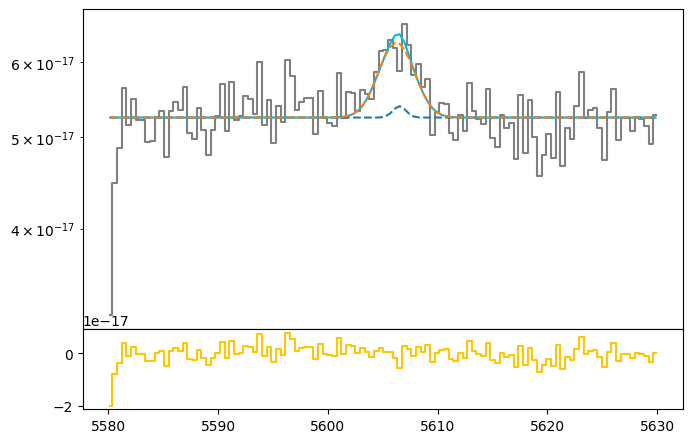

In [93]:
heii4685_nar_flux = out_heii4685.flatchain.Heii4685_nar.mean()
heii4685_nar_std = out_heii4685.flatchain.Heii4685_nar.std()

heii4685_brd_flux = out_heii4685.flatchain.Heii4685_brd.mean()
heii4685_brd_std = out_heii4685.flatchain.Heii4685_brd.std()

z_heii4685 = out_heii4685.flatchain.z_nar.mean()
z_heii4685_std = out_heii4685.flatchain.z_nar.std()

bkg_heii4685 = out_heii4685.flatchain.bkg.mean()
bkg_heii4685_std = out_heii4685.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(heii_4686.wavelength, heii_4686.flux, color='gray', label='Data', where='mid')

heii4685_nar = gaussian(heii_4686.wavelength, heii4685_nar_flux, wave_cat['HeII4685'], z_heii4685, upy.nominal_values(sigma_nar_4685))
heii4685_brd = gaussian(heii_4686.wavelength, heii4685_brd_flux, wave_cat['HeII4685'], z_heii4685 * z_ratio, upy.nominal_values(sigma_brd_4685))

heii4685 = heii4685_nar + heii4685_brd

ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685, color=c[0])
ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685_nar, ls='--')
ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685_brd, ls='--')
ax.set_yscale('log')
ax1.step(heii_4686.wavelength, heii_4686.flux - bkg_heii4685 - heii4685, color=c[3], where='mid')

In [94]:
# EW
EW_heii4685_nar = ufloat(heii4685_nar_flux, heii4685_nar_std) / ufloat(bkg_heii4685, bkg_heii4685_std)
EW_heii4685_brd = ufloat(heii4685_brd_flux, heii4685_brd_std) / ufloat(bkg_heii4685, bkg_heii4685_std)
EW_heii4685 = (ufloat(heii4685_nar_flux, heii4685_nar_std) + ufloat(heii4685_brd_flux, heii4685_brd_std)) / ufloat(bkg_heii4685, bkg_heii4685_std)

In [95]:
heii4685_tot_flux = ufloat(heii4685_nar_flux, heii4685_nar_std) + ufloat(heii4685_brd_flux, heii4685_brd_std)

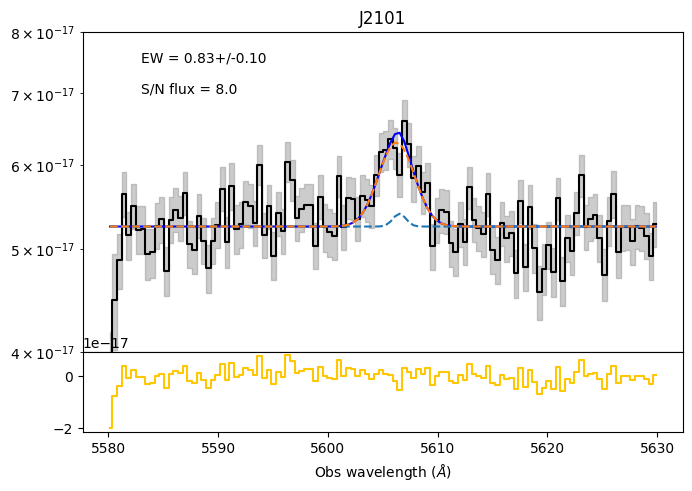

In [96]:
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(heii_4686.wavelength, heii_4686.flux, color='black', label='Data', where='mid')

heii4685_nar = gaussian(heii_4686.wavelength, heii4685_nar_flux, wave_cat['HeII4685'], z_heii4685, upy.nominal_values(sigma_nar_4685))
heii4685_brd = gaussian(heii_4686.wavelength, heii4685_brd_flux, wave_cat['HeII4685'], z_heii4685 * z_ratio, upy.nominal_values(sigma_brd_4685))

heii4685 = heii4685_nar + heii4685_brd

ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685, color='blue')
ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685_nar, ls='--')
ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685_brd, ls='--')
ax.set_yscale('log')
ax1.step(heii_4686.wavelength, heii_4686.flux - bkg_heii4685 - heii4685, color=c[3], where='mid')
ax.fill_between(heii_4686.wavelength, heii_4686.flux - heii_4686.noise,
                                      heii_4686.flux + heii_4686.noise,
                                      color='gray', alpha=0.4, step='mid')
ax.set_ylim(4e-17, 8e-17)
ax.set_title('J2101')
ax1.set_xlabel('Obs wavelength ($\AA$)')
ax.text(5583, 7.5e-17, s='EW = '+str(EW_heii4685))
ax.text(5583, 7e-17, s='S/N flux = '+str(round(heii4685_tot_flux.nominal_value/heii4685_tot_flux.std_dev, 2)))
fig.savefig('/home/benjamin/Documents/analogs/HeIIJ2101.pdf', bbox_inches='tight')

# [OII]3726 + [OII]3729

In [97]:
sigma_arc_3729 = (m * wave_cat['[OII]3729']*(1 + z_BN[igal])) + n

sigma_nar_3729 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3729**2))
sigma_brd_3729 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3729**2))

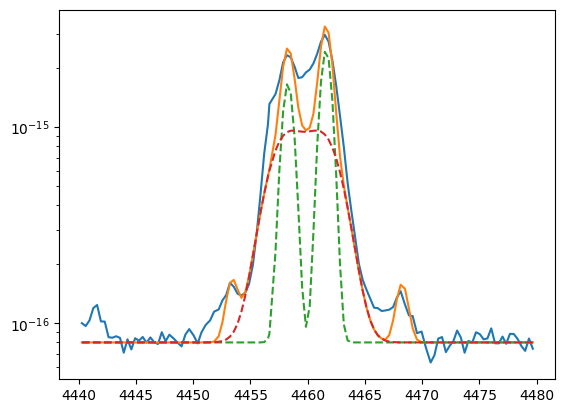

In [98]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 1e-16, wave_cat['H13'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, 3.0e-15, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, 3.0e-15, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, 2.0e-15, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, 3.0e-15, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, 1e-16, wave_cat['H14'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 8e-17

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')

plt.yscale('log')

In [99]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('H13', value=1e-16, min=0.)
params_oii_3727.add('Oiic_nar', value=3.0e-15, min=0.)
params_oii_3727.add('Oiic_brd', value=3.0e-15, min=0.)
params_oii_3727.add('Oiid_nar', value=2.0e-15, min=0.)
params_oii_3727.add('Oiid_brd', value=3.0e-15, min=0.)
params_oii_3727.add('H14', value=1e-16, min=0.)
params_oii_3727.add('bkg', value=8e-17, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [100]:
np.random.seed(2101)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:32<00:00, 76.26it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 51.10125627 161.96302192  87.34127427  67.30478846 120.02944401
 199.86839405  83.34214789  56.75042093]


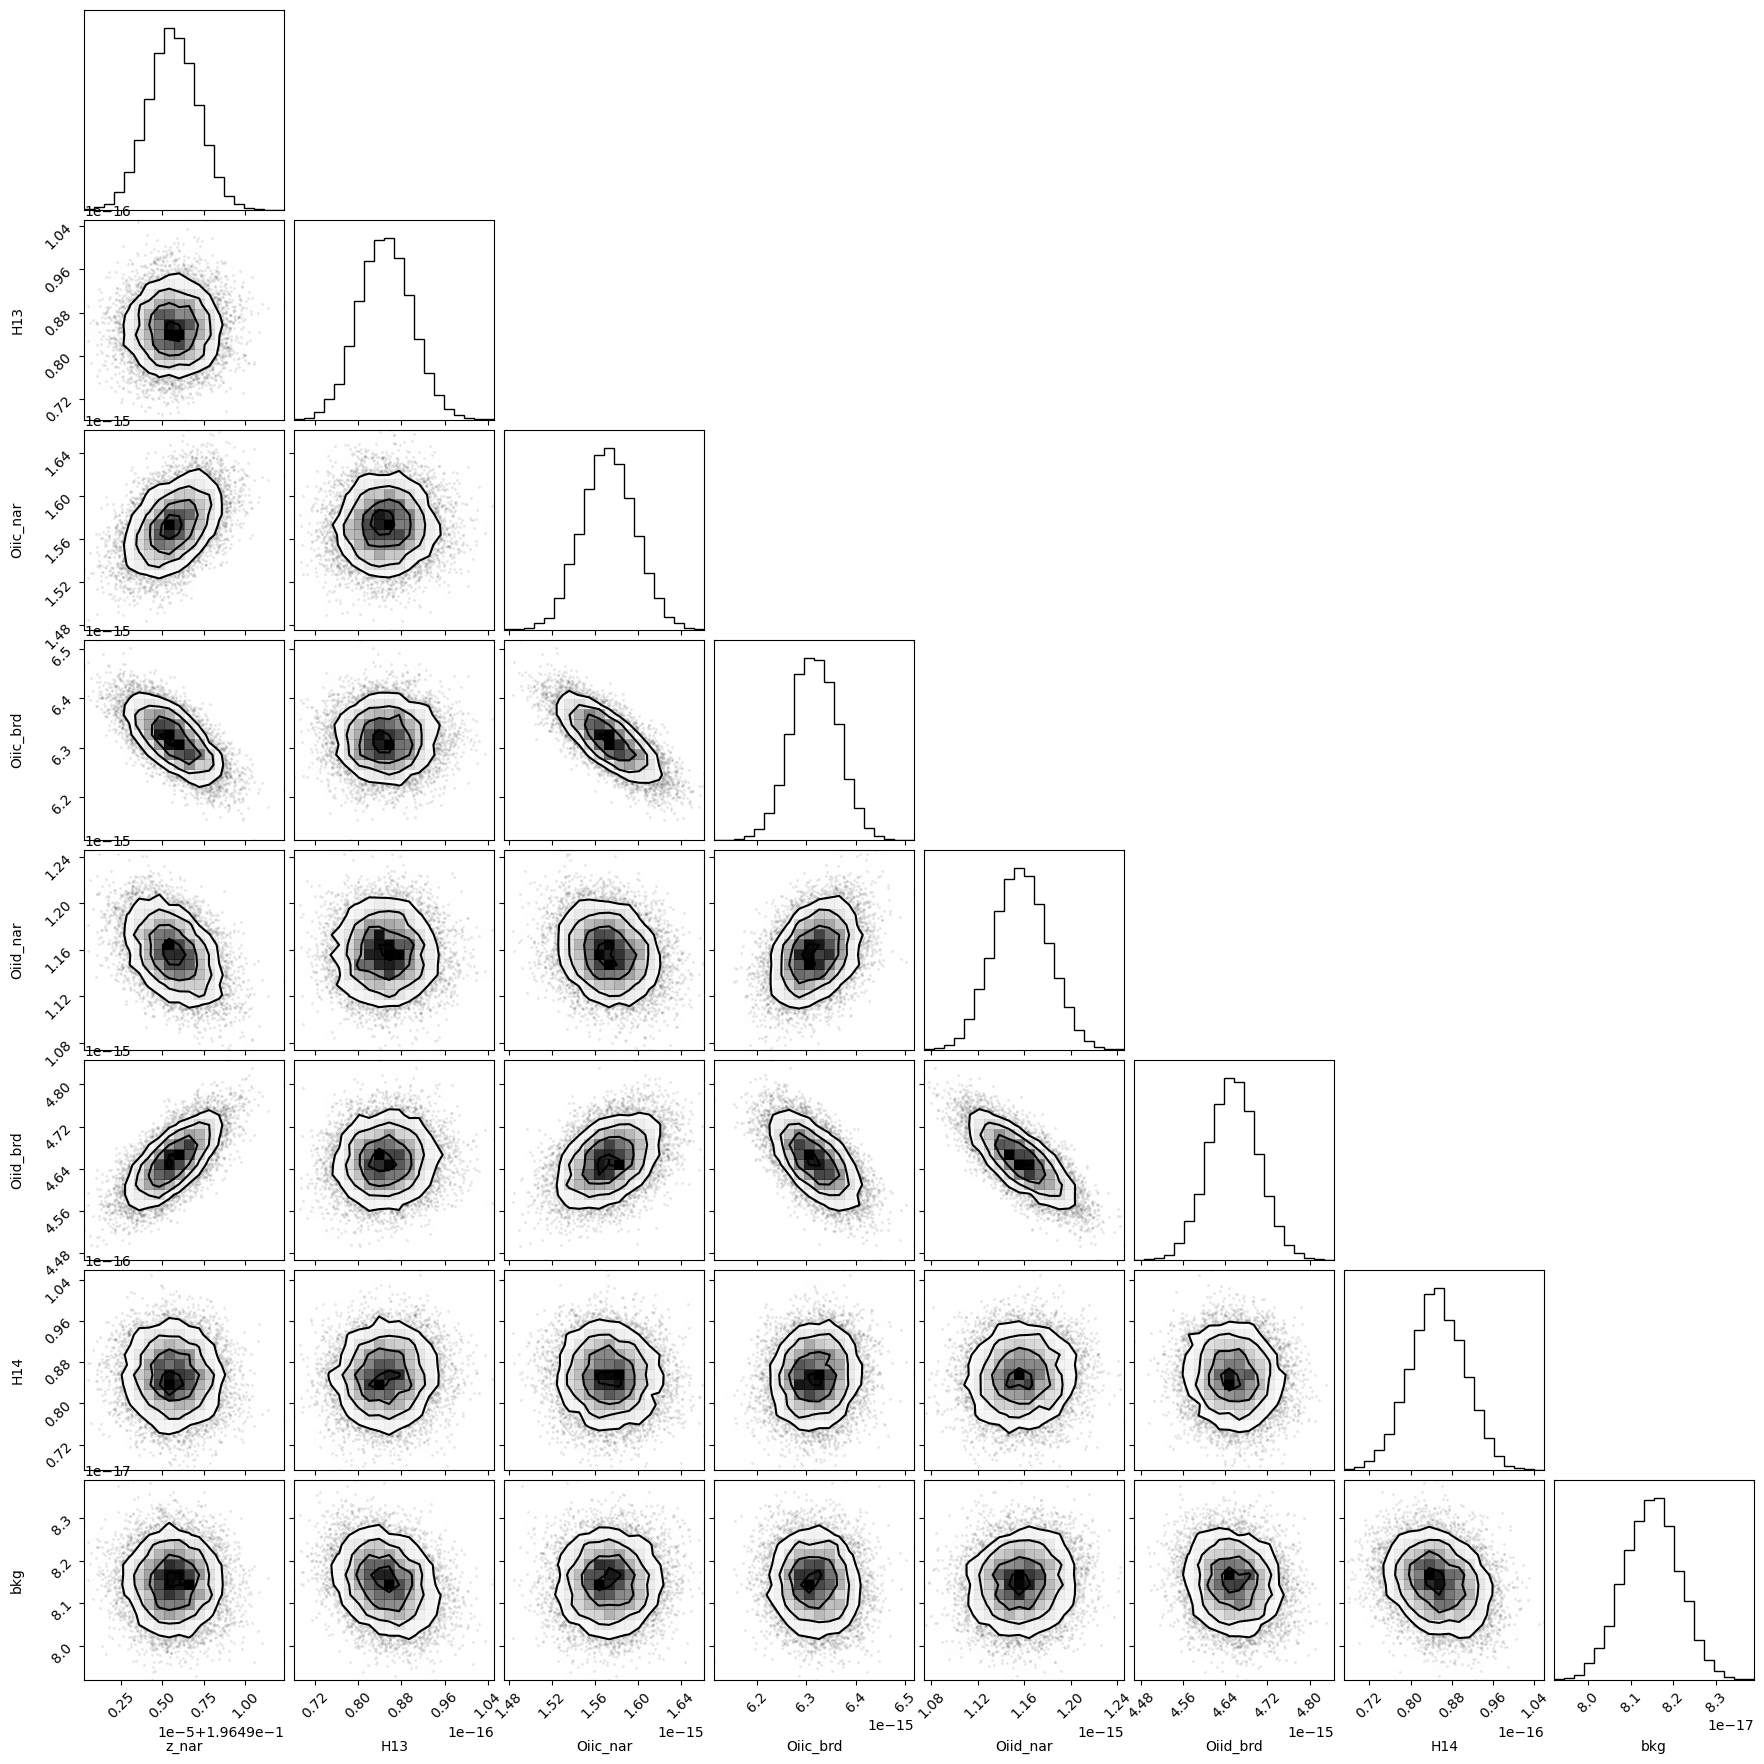

In [101]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

In [102]:
out_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19649565,1.4818e-06,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.49965991,,,0.49965990647669883,-inf,inf,False
sigma_brd,1.54428082,,,1.5442808227460738,-inf,inf,False
H13,8.5024e-17,4.8445e-18,(5.70%),1e-16,0.00000000,inf,True
Oiic_nar,1.5726e-15,2.4560e-17,(1.56%),3e-15,0.00000000,inf,True
Oiic_brd,6.3168e-15,4.6436e-17,(0.74%),3e-15,0.00000000,inf,True
Oiid_nar,1.1567e-15,2.3453e-17,(2.03%),2e-15,0.00000000,inf,True
Oiid_brd,4.6552e-15,4.6418e-17,(1.00%),3e-15,0.00000000,inf,True
H14,8.5219e-17,5.3341e-18,(6.26%),1e-16,0.00000000,inf,True


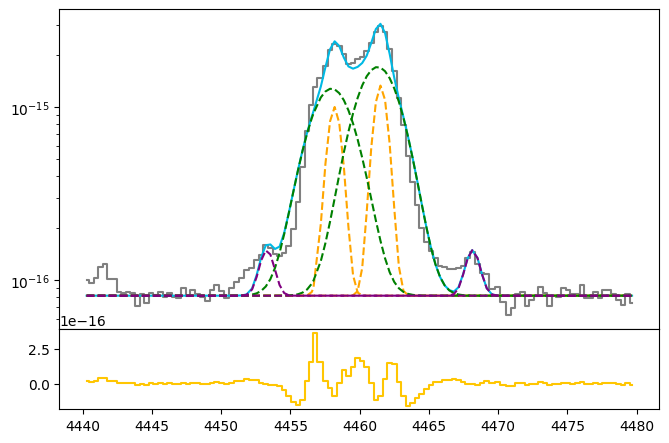

In [103]:
h13_flux = out_oii_3727.flatchain.H13.mean()
h13_std = out_oii_3727.flatchain.H13.std()

oiic_nar_flux = out_oii_3727.flatchain.Oiic_nar.mean()
oiic_nar_std = out_oii_3727.flatchain.Oiic_nar.std()

oiic_brd_flux = out_oii_3727.flatchain.Oiic_brd.mean()
oiic_brd_std = out_oii_3727.flatchain.Oiic_brd.std()

oiid_nar_flux = out_oii_3727.flatchain.Oiid_nar.mean()
oiid_nar_std = out_oii_3727.flatchain.Oiid_nar.std()

oiid_brd_flux = out_oii_3727.flatchain.Oiid_brd.mean()
oiid_brd_std = out_oii_3727.flatchain.Oiid_brd.std()

h14_flux = out_oii_3727.flatchain.H14.mean()
h14_std = out_oii_3727.flatchain.H14.std()

z_oii_3727 = out_oii_3727.flatchain.z_nar.mean()
z_oii_3727_std = out_oii_3727.flatchain.z_nar.std()

bkg_oii_3727 = out_oii_3727.flatchain.bkg.mean()
bkg_oii_3727_std = out_oii_3727.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14, color=c[3], where='mid')

In [104]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

# [OI]6300 + [SIII]6312

In [105]:
sigma_arc_6312 = (m * wave_cat['[SIII]6312']*(1 + z_BN[igal])) + n

sigma_nar_6312 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6312**2))
sigma_brd_6312 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6312**2))

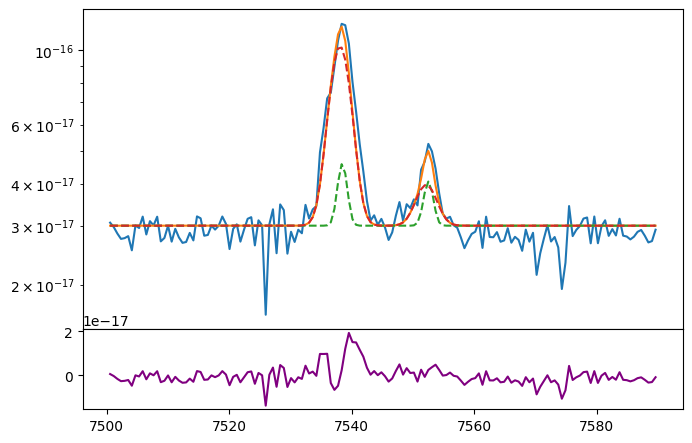

In [106]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 3e-17

oi_nar = gaussian(oi_siii.wavelength, 0.3e-16, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, 3e-16, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, 0.2e-16, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, 0.4e-16, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

ax.plot(oi_siii.wavelength, bkg + siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, bkg + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg + siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
ax.set_yscale('log')

In [107]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('Oi_nar', value=0.3e-16, min=0.)
params_oi_siii.add('Oi_brd', value=3.0e-16, min=0.)
params_oi_siii.add('Siiic_nar', value=0.2e-16, min=0.)
params_oi_siii.add('Siiic_brd', value=0.4e-16, min=0.)
params_oi_siii.add('bkg', value=3e-17, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_nar = params_oi_siii['sigma_nar']
    sigma_brd = params_oi_siii['sigma_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    bkg = params_oi_siii['bkg']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_brd)
    
    return (model_siii + model_oi + bkg - oi_siii.flux) / oi_siii.noise

In [108]:
np.random.seed(2101)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:24<00:00, 100.84it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 62.91518068 117.67235328 110.52879835  57.39319635  67.81404788
  69.91572885]


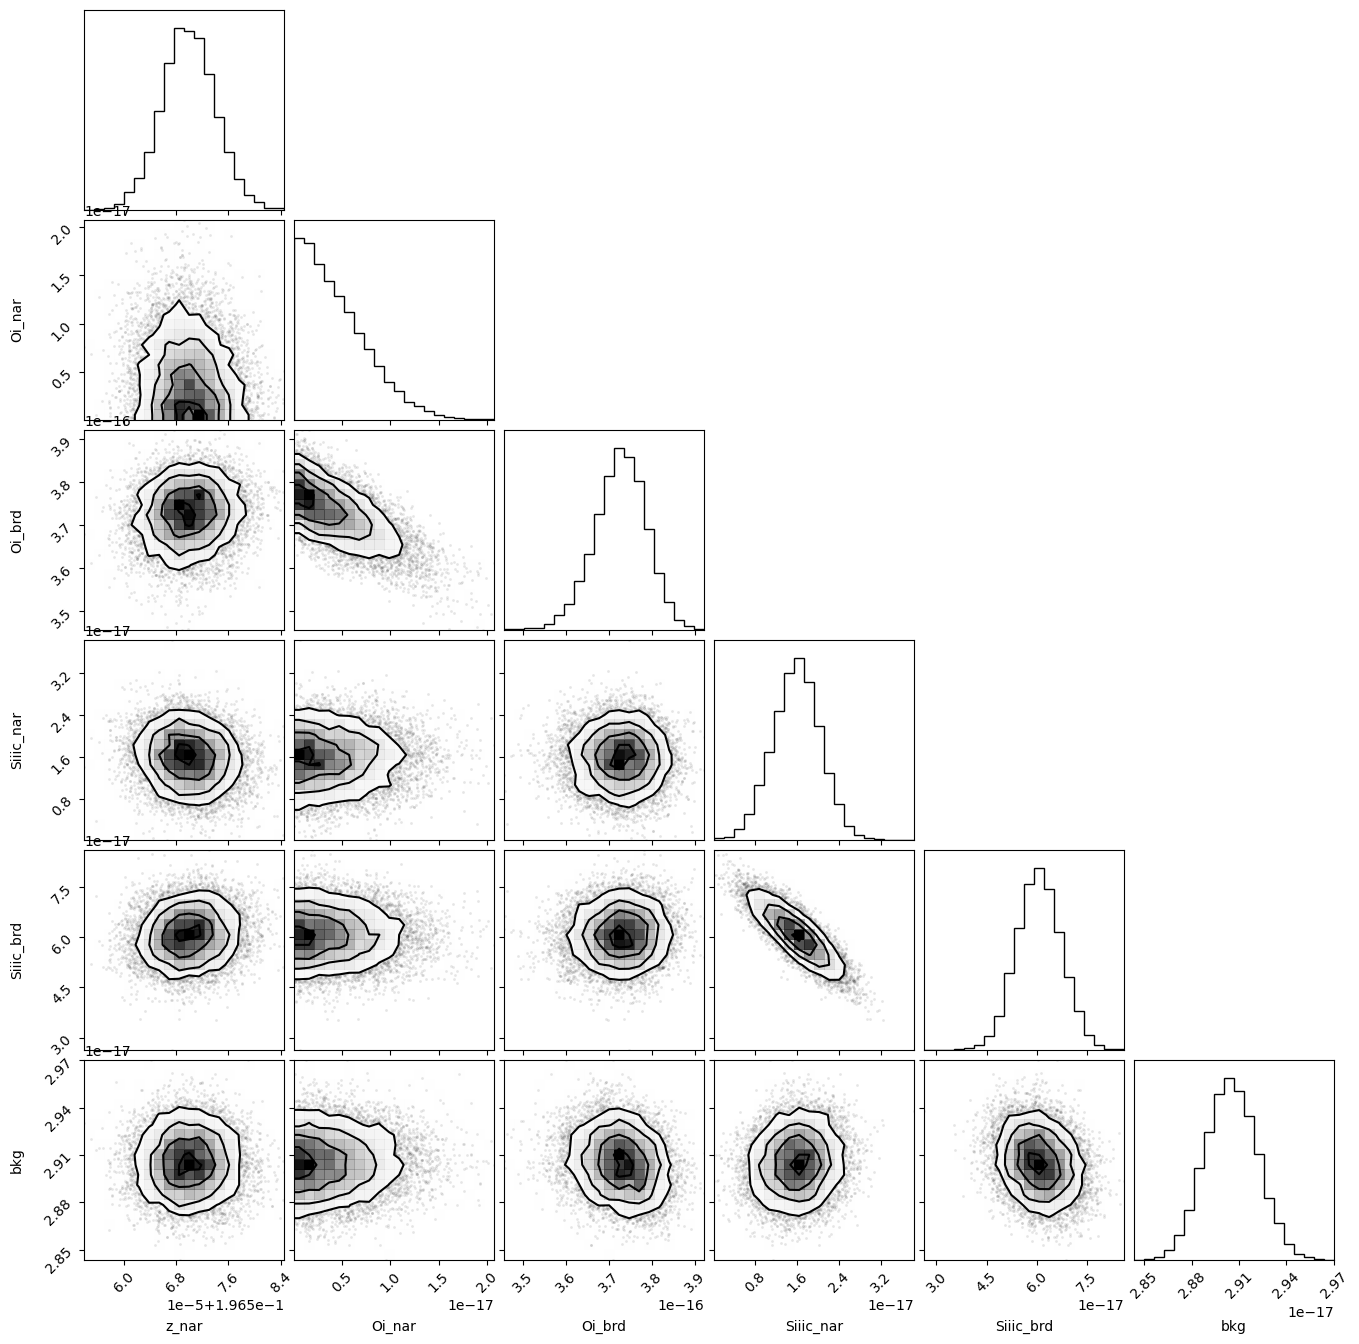

In [109]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [110]:
out_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19656986,4.0188e-06,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.75064985,,,0.7506498500196112,-inf,inf,False
sigma_brd,1.64274722,,,1.642747221788992,-inf,inf,False
Oi_nar,3.8110e-18,3.4554e-18,(90.67%),3e-17,0.00000000,inf,True
Oi_brd,3.7286e-16,5.9021e-18,(1.58%),3e-16,0.00000000,inf,True
Siiic_nar,1.5981e-17,4.4958e-18,(28.13%),2e-17,0.00000000,inf,True
Siiic_brd,6.0673e-17,6.6945e-18,(11.03%),4e-17,0.00000000,inf,True
bkg,2.9050e-17,1.6654e-19,(0.57%),3e-17,0.00000000,inf,True


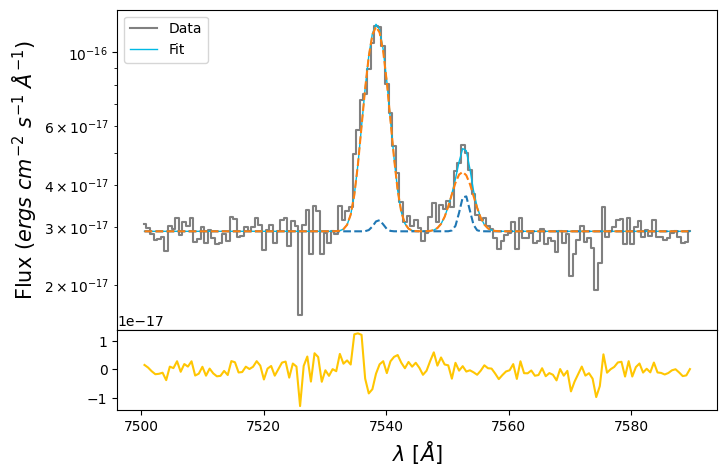

In [111]:
oi_nar_flux = out_oi_siii.flatchain.Oi_nar.mean()
oi_nar_std = out_oi_siii.flatchain.Oi_nar.std()

oi_brd_flux = out_oi_siii.flatchain.Oi_brd.mean()
oi_brd_std = out_oi_siii.flatchain.Oi_brd.std()

siiic_nar_flux = out_oi_siii.flatchain.Siiic_nar.mean()
siiic_nar_std = out_oi_siii.flatchain.Siiic_nar.std()

siiic_brd_flux = out_oi_siii.flatchain.Siiic_brd.mean()
siiic_brd_std = out_oi_siii.flatchain.Siiic_brd.std()

z_oi_siii = out_oi_siii.flatchain.z_nar.mean()
z_oi_siii_std = out_oi_siii.flatchain.z_nar.std()

bkg_oi_siii = out_oi_siii.flatchain.bkg.mean()
bkg_oi_siii_std = out_oi_siii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oi_nar = gaussian(oi_siii.wavelength, oi_nar_flux, wave_cat['[OI]6300'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, oi_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

oi = oi_nar + oi_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic + oi,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_brd + oi_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg_oi_siii - siiic - oi,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [112]:
# EW
EW_OI_6300_nar = ufloat(oi_nar_flux, oi_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300_brd = ufloat(oi_brd_flux, oi_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300 = (ufloat(oi_nar_flux, oi_nar_std) + ufloat(oi_brd_flux, oi_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

EW_SIII_6312_nar = ufloat(siiic_nar_flux, siiic_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312_brd = ufloat(siiic_brd_flux, siiic_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312 = (ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

# [OIII]5007 + HeI 5015

In [113]:
sigma_arc_5007 = (m * wave_cat['[OIII]5007']*(1 + z_BN[igal])) + n

sigma_nar_5007 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5007**2))
sigma_brd_5007 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5007**2))

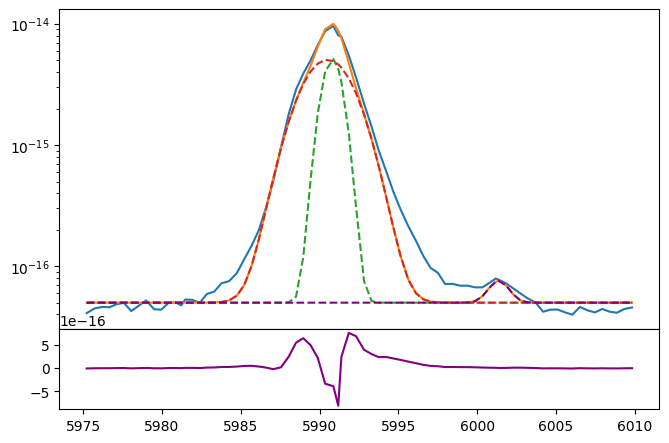

In [114]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 5e-17

oiiia_nar = gaussian(oiii_hei.wavelength, 8e-15, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, 2e-14, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5007))

hei_5015 = gaussian(oiii_hei.wavelength, 4e-17, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))

ax.plot(oiii_hei.wavelength, bkg + oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, bkg + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg + hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiiia_nar - oiiia_brd - hei_5015, color='purple')
ax.set_yscale('log')

In [115]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_nar', value=upy.nominal_values(sigma_nar_5007), vary=False)
params_oiii_hei.add('sigma_brd', value=upy.nominal_values(sigma_brd_5007), vary=False)
params_oiii_hei.add('Hei', value=4e-17, min=0.)
params_oiii_hei.add('Oiiia_nar', value=8.0e-15, min=0.)
params_oiii_hei.add('Oiiia_brd', value=2.0e-14, min=0.)
params_oiii_hei.add('bkg', value=5e-17, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_nar = params_oiii_hei['sigma_nar']
    sigma_brd = params_oiii_hei['sigma_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_nar)
    
    return (model_oiii + model_hei + bkg - oiii_hei.flux) / oiii_hei.noise

In [116]:
np.random.seed(2101)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 111.09it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 68.59166945  36.36461195  92.84520409  87.88785381 113.94185792]


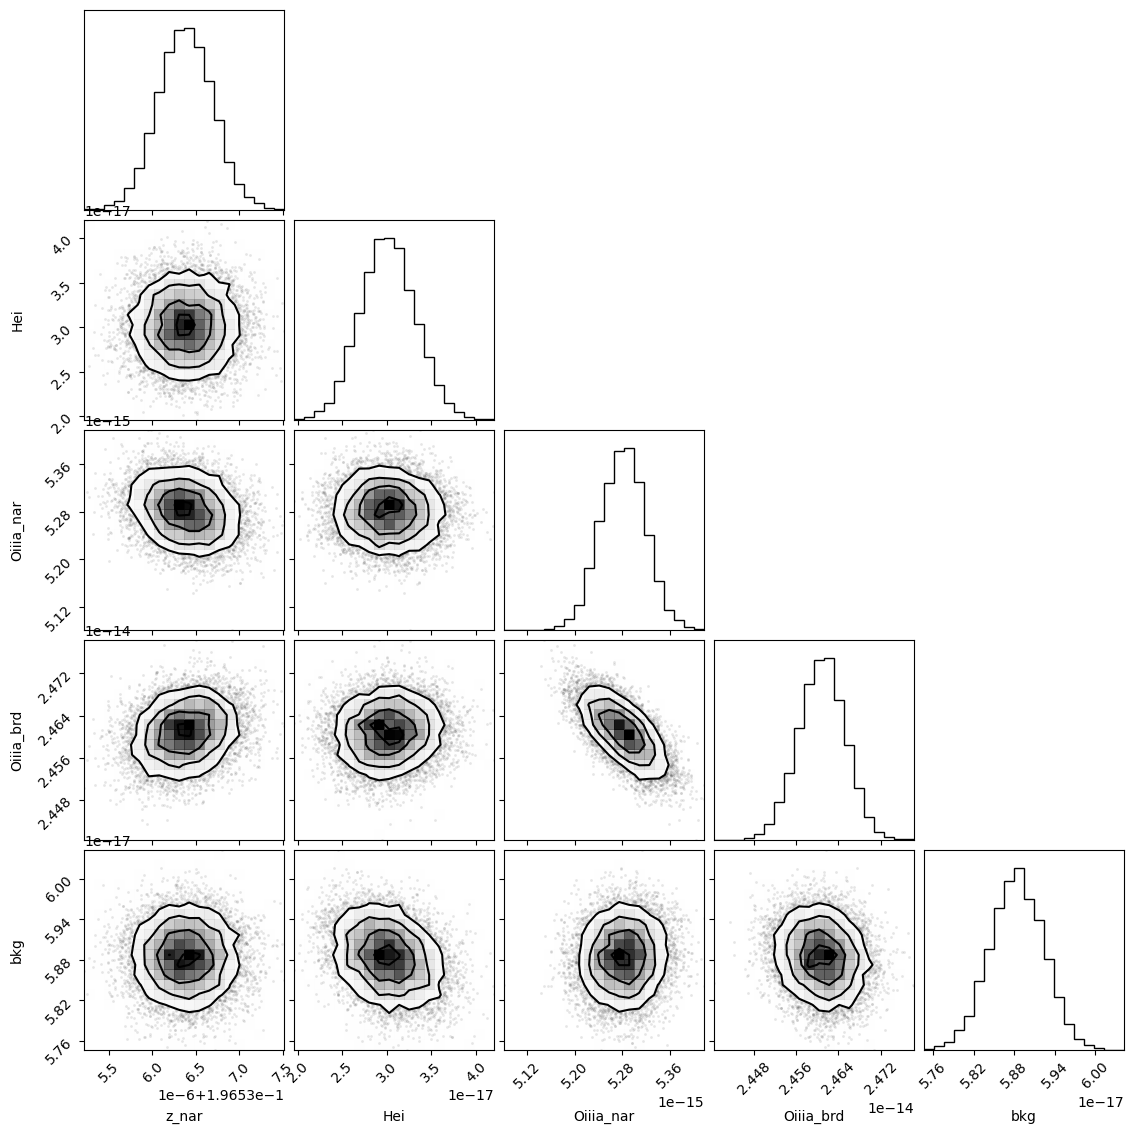

In [117]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [118]:
out_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19653638,3.0867e-07,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.62262368,,,0.6226236771230959,-inf,inf,False
sigma_brd,1.58833355,,,1.588333554602204,-inf,inf,False
Hei,3.0110e-17,3.1378e-18,(10.42%),4e-17,0.00000000,inf,True
Oiiia_nar,5.2813e-15,3.6910e-17,(0.70%),8e-15,0.00000000,inf,True
Oiiia_brd,2.4609e-14,4.4413e-17,(0.18%),2e-14,0.00000000,inf,True
bkg,5.8847e-17,4.0043e-19,(0.68%),5e-17,0.00000000,inf,True


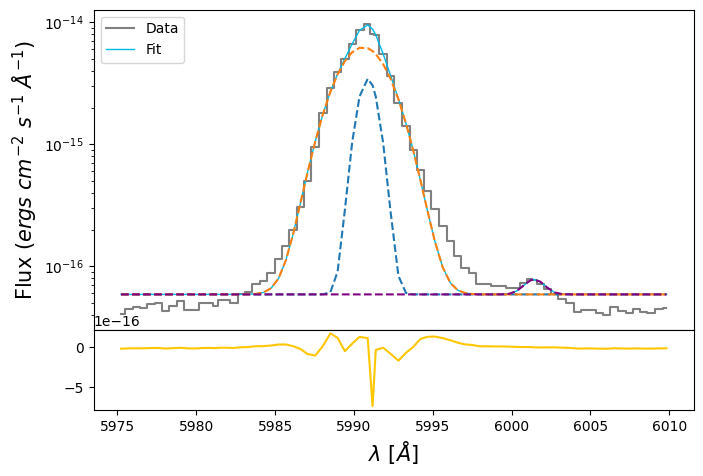

In [119]:
hei_flux = out_oiii_hei.flatchain.Hei.mean()
hei_std = out_oiii_hei.flatchain.Hei.std()

oiiia_nar_flux = out_oiii_hei.flatchain.Oiiia_nar.mean()
oiiia_nar_std = out_oiii_hei.flatchain.Oiiia_nar.std()

oiiia_brd_flux = out_oiii_hei.flatchain.Oiiia_brd.mean()
oiiia_brd_std = out_oiii_hei.flatchain.Oiiia_brd.std()

z_oiii_hei = out_oiii_hei.flatchain.z_nar.mean()
z_oiii_hei_std = out_oiii_hei.flatchain.z_nar.std()

bkg_oiii_hei = out_oiii_hei.flatchain.bkg.mean()
bkg_oiii_hei_std = out_oiii_hei.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, upy.nominal_values(sigma_brd_5007))

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [120]:
# EW
EW_OIII_5007_nar = ufloat(oiiia_nar_flux, oiiia_nar_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007_brd = ufloat(oiiia_brd_flux, oiiia_brd_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007 = (ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)

# [OIII]4363

In [121]:
sigma_arc_4363 = (m * wave_cat['[OIII]4363']*(1 + z_BN[igal])) + n

sigma_nar_4363 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4363**2))
sigma_brd_4363 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4363**2))

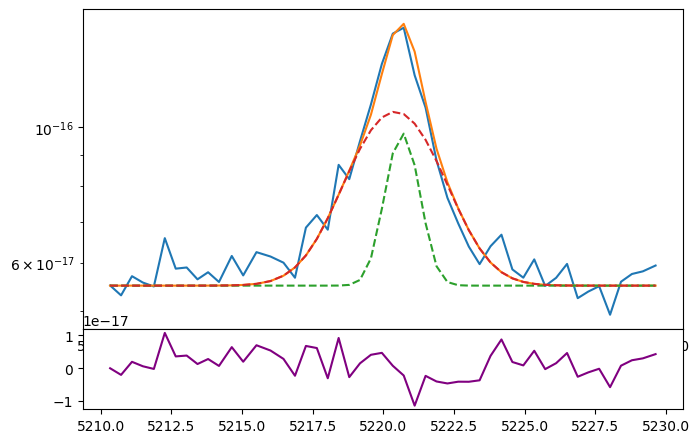

In [122]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)
bkg = 5.5e-17

oiiic_nar = gaussian(oiii_4363.wavelength, 0.6e-16, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, 2.0e-16, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4363))

ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + oiiic_brd)
ax.plot(oiii_4363.wavelength, bkg + oiiic_nar, ls='--')
ax.plot(oiii_4363.wavelength, bkg + oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - bkg - oiiic_nar - oiiic_brd, color='purple')
ax.set_yscale('log')

In [123]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_nar', value=upy.nominal_values(sigma_nar_4363), vary=False)
params_oiiic.add('sigma_brd', value=upy.nominal_values(sigma_brd_4363), vary=False)
params_oiiic.add('Oiiic_nar', value=0.6e-16, min=0.)
params_oiiic.add('Oiiic_brd', value=2.0e-16, min=0.)
params_oiiic.add('bkg', value=5.5e-17, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_nar = params_oiiic['sigma_nar']
    sigma_brd = params_oiiic['sigma_brd']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    bkg = params_oiiic['bkg']
    
    x = oiii_4363.wavelength
    model = gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4363.flux) / oiii_4363.noise

In [124]:
np.random.seed(2101)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 131.72it/s]


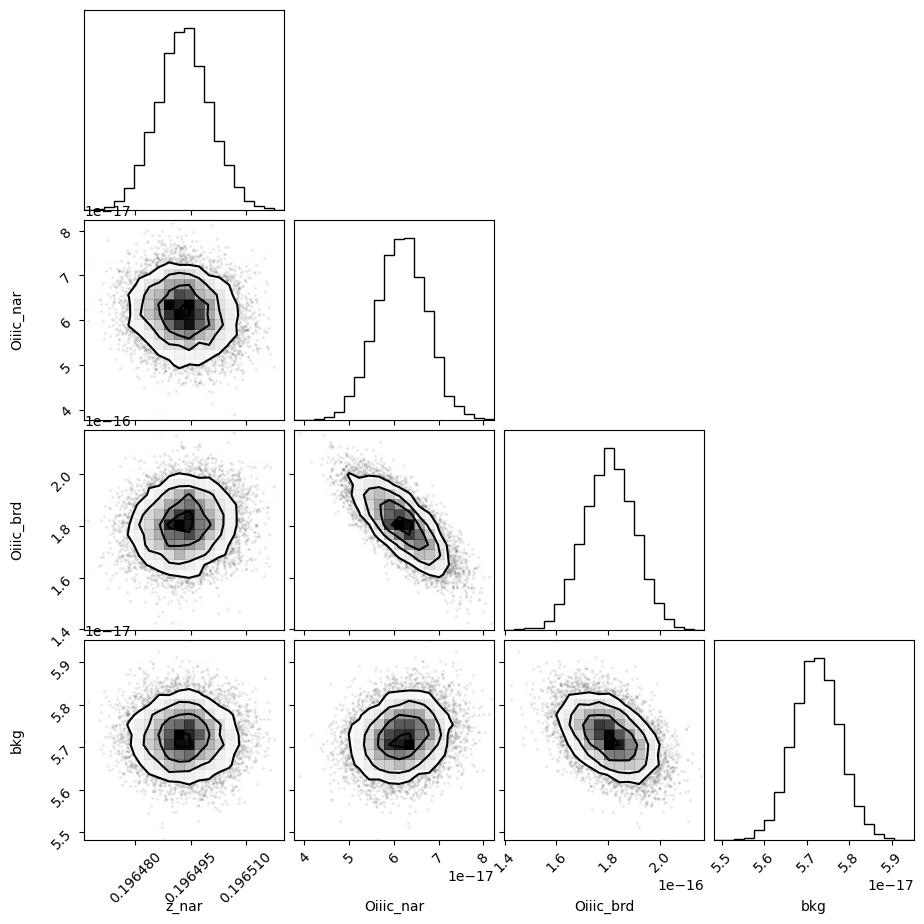

In [125]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [126]:
out_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.19649311,7.2037e-06,(0.00%),0.19652130752330071,-inf,inf,True
z_ratio,0.99970669,,,0.9997066859097692,-inf,inf,False
sigma_nar,0.56030115,,,0.5603011526134061,-inf,inf,False
sigma_brd,1.56495387,,,1.5649538711990518,-inf,inf,False
Oiiic_nar,6.1798e-17,5.5617e-18,(9.00%),6e-17,0.00000000,inf,True
Oiiic_brd,1.8078e-16,9.8018e-18,(5.42%),2e-16,0.00000000,inf,True
bkg,5.7238e-17,5.4079e-19,(0.94%),5.5e-17,0.00000000,inf,True


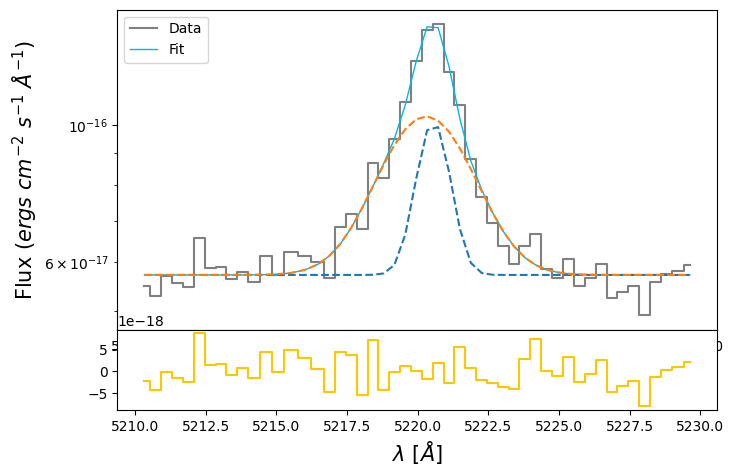

In [127]:
oiiic_nar_flux = out_oiiic.flatchain.Oiiic_nar.mean()
oiiic_nar_std = out_oiiic.flatchain.Oiiic_nar.std()

oiiic_brd_flux = out_oiiic.flatchain.Oiiic_brd.mean()
oiiic_brd_std = out_oiiic.flatchain.Oiiic_brd.std()

z_oiii = out_oiiic.flatchain.z_nar.mean()
z_oiii_std = out_oiiic.flatchain.z_nar.std()

bkg_oiiic = out_oiiic.flatchain.bkg.mean()
bkg_oiiic_std = out_oiiic.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, upy.nominal_values(sigma_brd_4363))
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_nar, ls='--')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - bkg_oiiic - oiiic, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [128]:
# EW
EW_OIII_4363_nar = ufloat(oiiic_nar_flux, oiiic_nar_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363_brd = ufloat(oiiic_brd_flux, oiiic_brd_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363 = (ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / ufloat(bkg_oiiic, bkg_oiiic_std)

# Temperatures and stuff

In [4]:
from magE.functions import *
from magE.functions import calzetti2000 as k_cal

# Extinction
ext_cat = pd.read_csv(magePath+'results/dust_norm_cal_lines.csv')
index = np.argmax(ext_cat['galname'] == galname)
E_BV = ext_cat['E_BV'][index]

if E_BV < 0:
    E_BV = 0

In [132]:
heiia_nar_chain = out_heii4685.flatchain.Heii4685_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeII4685']))
heiia_brd_chain = out_heii4685.flatchain.Heii4685_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeII4685']))
heiia_tot_chain = heiia_nar_chain + heiia_brd_chain

heia_nar_chain = out_hei7065.flatchain.Hei7065_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI7065']))
heia_brd_chain = out_hei7065.flatchain.Hei7065_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI7065']))
heia_tot_chain = heia_nar_chain + heia_brd_chain

heib_nar_chain = out_hei6678.flatchain.Hei6678_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI6678']))
heib_brd_chain = out_hei6678.flatchain.Hei6678_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI6678']))
heib_tot_chain = heib_nar_chain + heib_brd_chain

heic_nar_chain = out_hei5875.flatchain.Hei5875_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI5875']))
heic_brd_chain = out_hei5875.flatchain.Hei5875_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI5875']))
heic_tot_chain = heic_nar_chain + heic_brd_chain

heid_nar_chain = out_hei4471.flatchain.Hei4471_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI4471']))
heid_brd_chain = out_hei4471.flatchain.Hei4471_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['HeI4471']))
heid_tot_chain = heid_nar_chain + heid_brd_chain

oiiia_nar_chain = out_oiii_hei.flatchain.Oiiia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_brd_chain = out_oiii_hei.flatchain.Oiiia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_tot_chain = oiiia_nar_chain + oiiia_brd_chain

oiiib_nar_chain = out_oiii_4959.flatchain.Oiiib_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_brd_chain = out_oiii_4959.flatchain.Oiiib_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_tot_chain = oiiib_nar_chain + oiiib_brd_chain

oiiic_nar_chain = out_oiiic.flatchain.Oiiic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_brd_chain = out_oiiic.flatchain.Oiiic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_tot_chain = oiiic_nar_chain + oiiic_brd_chain

siia_nar_chain = out_sii.flatchain.Siia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_brd_chain = out_sii.flatchain.Siia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_tot_chain = siia_nar_chain + siia_brd_chain

siib_nar_chain = out_sii.flatchain.Siib_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_brd_chain = out_sii.flatchain.Siib_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_tot_chain = siib_nar_chain + siib_brd_chain

oiia_nar_chain = out_oii_7320.flatchain.Oiia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_brd_chain = out_oii_7320.flatchain.Oiia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_tot_chain = oiia_nar_chain + oiia_brd_chain

oiib_nar_chain = out_oii_7320.flatchain.Oiib_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_brd_chain = out_oii_7320.flatchain.Oiib_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_tot_chain = oiib_nar_chain + oiib_brd_chain

oiic_nar_chain = out_oii_3727.flatchain.Oiic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_brd_chain = out_oii_3727.flatchain.Oiic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_tot_chain = oiic_nar_chain + oiic_brd_chain

oiid_nar_chain = out_oii_3727.flatchain.Oiid_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_brd_chain = out_oii_3727.flatchain.Oiid_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_tot_chain = oiid_nar_chain + oiid_brd_chain

siiic_nar_chain = out_oi_siii.flatchain.Siiic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_brd_chain = out_oi_siii.flatchain.Siiic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_tot_chain = siiic_nar_chain + siiic_brd_chain

niia_nar_chain = out_ha_nii.flatchain.Niia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6584']))
niia_brd_chain = out_ha_nii.flatchain.Niia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6584']))
niia_tot_chain = niia_nar_chain + niia_brd_chain

niib_nar_chain = out_ha_nii.flatchain.Niia_nar[1000:] * out_ha_nii.flatchain.Niib_to_niia[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6548']))
niib_brd_chain = out_ha_nii.flatchain.Niia_brd[1000:] * out_ha_nii.flatchain.Niib_to_niia[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6548']))
niib_tot_chain = niib_nar_chain + niib_brd_chain

niic_nar_chain = out_nii.flatchain.Niic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]5755']))
niic_brd_chain = out_nii.flatchain.Niic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]5755']))
niic_tot_chain = niic_nar_chain + niic_brd_chain

hb_nar_chain = out_hb.flatchain.Hb_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_brd_chain = out_hb.flatchain.Hb_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_tot_chain = hb_nar_chain + hb_brd_chain

ha_nar_chain = out_ha_nii.flatchain.Ha_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['Ha']))
ha_brd_chain = out_ha_nii.flatchain.Ha_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['Ha']))
ha_tot_chain = ha_nar_chain + ha_brd_chain

In [134]:
chains_dict = {'[OII]3726_nar': oiid_nar_chain.to_numpy(),
               '[OII]3726_brd': oiid_brd_chain.to_numpy(),
               '[OII]3726': oiid_tot_chain.to_numpy(),
               
               '[OII]3729_nar': oiic_nar_chain.to_numpy(),
               '[OII]3729_brd': oiic_brd_chain.to_numpy(),
               '[OII]3729': oiic_tot_chain.to_numpy(),
               
               '[OIII]4363_nar': oiiic_nar_chain.to_numpy(),
               '[OIII]4363_brd': oiiic_brd_chain.to_numpy(),
               '[OIII]4363': oiiic_tot_chain.to_numpy(),
               
               'HeI4471_nar': heid_nar_chain.to_numpy(),
               'HeI4471_brd': heid_brd_chain.to_numpy(),
               'HeI4471': heid_tot_chain.to_numpy(),
               
               'HeII4686_nar': heiia_nar_chain.to_numpy(),
               'HeII4686_brd': heiia_brd_chain.to_numpy(),
               'HeII4686': heiia_tot_chain.to_numpy(),
               
               'Hb_nar': hb_nar_chain.to_numpy(),
               'Hb_brd': hb_brd_chain.to_numpy(),
               'Hb': hb_tot_chain.to_numpy(),
               
               '[OIII]4959_nar': oiiib_nar_chain.to_numpy(),
               '[OIII]4959_brd': oiiib_brd_chain.to_numpy(),
               '[OIII]4959': oiiib_tot_chain.to_numpy(),
               
               '[OIII]5007_nar': oiiia_nar_chain.to_numpy(),
               '[OIII]5007_brd': oiiia_brd_chain.to_numpy(),
               '[OIII]5007': oiiia_tot_chain.to_numpy(),
               
               '[NII]5755_nar': niic_nar_chain.to_numpy(),
               '[NII]5755_brd': niic_brd_chain.to_numpy(),
               '[NII]5755': niic_tot_chain.to_numpy(),
               
               'HeI5875_nar': heic_nar_chain.to_numpy(),
               'HeI5875_brd': heic_brd_chain.to_numpy(),
               'HeI5875': heic_tot_chain.to_numpy(),
               
               '[SIII]6312_nar': siiic_nar_chain.to_numpy(),
               '[SIII]6312_brd': siiic_brd_chain.to_numpy(),
               '[SIII]6312': siiic_tot_chain.to_numpy(),
               
               
               '[NII]6548_nar': niib_nar_chain.to_numpy(),
               '[NII]6548_brd': niib_brd_chain.to_numpy(),
               '[NII]6548': niib_tot_chain.to_numpy(),
               
               'Ha_nar': ha_nar_chain.to_numpy(),
               'Ha_brd': ha_brd_chain.to_numpy(),
               'Ha': ha_tot_chain.to_numpy(),
               
               '[NII]6584_nar': niia_nar_chain.to_numpy(),
               '[NII]6584_brd': niia_brd_chain.to_numpy(),
               '[NII]6584': niia_tot_chain.to_numpy(),
               
               'HeI6678_nar': heib_nar_chain.to_numpy(),
               'HeI6678_brd': heib_brd_chain.to_numpy(),
               'HeI6678': heib_tot_chain.to_numpy(),
               
               '[SII]6716_nar': siib_nar_chain.to_numpy(),
               '[SII]6716_brd': siib_brd_chain.to_numpy(),
               '[SII]6716': siib_tot_chain.to_numpy(),
               
               '[SII]6730_nar': siia_nar_chain.to_numpy(),
               '[SII]6730_brd': siia_brd_chain.to_numpy(),
               '[SII]6730': siia_tot_chain.to_numpy(),
               
               'HeI7065_nar': heia_nar_chain.to_numpy(),
               'HeI7065_brd': heia_brd_chain.to_numpy(),
               'HeI7065': heia_tot_chain.to_numpy(),
               
               '[OII]7319_nar': oiib_nar_chain.to_numpy(),
               '[OII]7319_brd': oiib_brd_chain.to_numpy(),
               '[OII]7319': oiib_tot_chain.to_numpy(),
               
               '[OII]7330_nar': oiia_nar_chain.to_numpy(),
               '[OII]7330_brd': oiia_brd_chain.to_numpy(),
               '[OII]7330': oiia_tot_chain.to_numpy(),
               
               '[SIII]9069_nar': np.nan * np.ones(9000),
               '[SIII]9069_brd': np.nan * np.ones(9000),
               '[SIII]9069': np.nan * np.ones(9000),
               
               '[SIII]9532_nar': np.nan * np.ones(9000),
               '[SIII]9532_brd': np.nan * np.ones(9000),
               '[SIII]9532': np.nan * np.ones(9000)
}
chains_dict_pd = pd.DataFrame(data=chains_dict, index=None)
chains_dict_pd.to_csv('/home/benjamin/Documents/chains/chains_J2101.csv')
#save_catalog(galname, chains_dict_pd, '/home/benjamin/Documents/chains/chains_J0021.csv')

In [135]:
lines_dict = {'galname': galname,
              '[OII]3726': oiid_tot_chain.mean(),
              '[OII]3726_err': oiid_tot_chain.std(),
              '[OII]3729': oiic_tot_chain.mean(),
              '[OII]3729_err': oiic_tot_chain.std(),
              '[OIII]4363': oiiic_tot_chain.mean(),
              '[OIII]4363_err': oiiic_tot_chain.std(),
              'HeI4471': heid_tot_chain.mean(),
              'HeI4471_err': heid_tot_chain.std(),
              'HeII4686': heiia_tot_chain.mean(),
              'HeII4686_err': heiia_tot_chain.std(),
              'Hb': hb_tot_chain.mean(),
              'Hb_err': hb_tot_chain.std(),
              '[OIII]4959': oiiib_tot_chain.mean(),
              '[OIII]4959_err': oiiib_tot_chain.std(),
              '[OIII]5007': oiiia_tot_chain.mean(),
              '[OIII]5007_err': oiiia_tot_chain.std(),
              '[NII]5575': niic_tot_chain.mean(),
              '[NII]5575_err': niic_tot_chain.std(),
              'HeI5875': heic_tot_chain.mean(),
              'HeI5875_err': heic_tot_chain.std(),
              '[SIII]6312': siiic_tot_chain.mean(),
              '[SIII]6312_err': siiic_tot_chain.std(),
              '[NII]6548': niib_tot_chain.mean(),
              '[NII]6548_err': niib_tot_chain.std(),
              'Ha': ha_tot_chain.mean(),
              'Ha_err': ha_tot_chain.std(),
              '[NII]6584': niia_tot_chain.mean(),
              '[NII]6584_err': niia_tot_chain.std(),
              'HeI6678': heib_tot_chain.mean(),
              'HeI6678_err': heib_tot_chain.std(),
              '[SII]6716': siib_tot_chain.mean(),
              '[SII]6716_err': siib_tot_chain.std(),
              '[SII]6730': siia_tot_chain.mean(),
              '[SII]6730_err': siia_tot_chain.std(),
              'HeI7065': heia_tot_chain.mean(),
              'HeI7065_err': heia_tot_chain.std(),
              '[OII]7319': oiib_tot_chain.mean(),
              '[OII]7319_err': oiib_tot_chain.std(),
              '[OII]7330': oiia_tot_chain.mean(),
              '[OII]7330_err': oiia_tot_chain.std(),
              '[SIII]9069': None,
              '[SIII]9069_err': None,
              '[SIII]9532': None,
              '[SIII]9532_err': None
              
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, magePath + '/results/lines_final.csv')

Existent catalog (.csv) file.
Existent data for J2101, overwriting...
Done.


# Start here

In [5]:
# Reading the chains
import pandas as pd 
chains = pd.read_csv('/home/benjamin/Documents/chains/chains_J2101.csv')

In [6]:
t_OIII_nar = TO3(chains['[OIII]5007_nar'].to_numpy(), chains['[OIII]4959_nar'].to_numpy(), chains['[OIII]4363_nar'].to_numpy())
t_OIII_brd = TO3(chains['[OIII]5007_brd'].to_numpy(), chains['[OIII]4959_brd'].to_numpy(), chains['[OIII]4363_brd'].to_numpy())
t_OIII_tot = TO3(chains['[OIII]5007'].to_numpy()    , chains['[OIII]4959'].to_numpy()    , chains['[OIII]4363'].to_numpy())

O2_H_nar = 10**(double_log_OH(chains['[OIII]5007_nar'].to_numpy(), chains['[OIII]4959_nar'].to_numpy(), chains['Hb_nar'].to_numpy(), t_OIII_nar) - 12)
O2_H_brd = 10**(double_log_OH(chains['[OIII]5007_brd'].to_numpy(), chains['[OIII]4959_brd'].to_numpy(), chains['Hb_brd'].to_numpy(), t_OIII_brd) - 12)
O2_H_tot = 10**(double_log_OH(chains['[OIII]5007'].to_numpy()    , chains['[OIII]4959'].to_numpy()    , chains['Hb'].to_numpy()    , t_OIII_tot) - 12)

IO2_R_nar = 9.36 * (t_OIII_nar**0.44) * O2_H_nar * chains['Hb_nar'].to_numpy()
IO2_R_brd = 9.36 * (t_OIII_brd**0.44) * O2_H_brd * chains['Hb_brd'].to_numpy()
IO2_R_tot = 9.36 * (t_OIII_tot**0.44) * O2_H_tot * chains['Hb'].to_numpy()    

den_nar = ne(chains['[SII]6730_nar'].to_numpy(), chains['[SII]6716_nar'].to_numpy(), t_OIII_nar)
den_brd = ne(chains['[SII]6730_brd'].to_numpy(), chains['[SII]6716_brd'].to_numpy(), t_OIII_brd)
den_tot = ne(chains['[SII]6730'].to_numpy()    , chains['[SII]6716'].to_numpy()    , t_OIII_tot)

t_OII_nar = TO2(chains['[OII]7330_nar'].to_numpy(), chains['[OII]7319_nar'].to_numpy(), chains['[OII]3729_nar'].to_numpy(), chains['[OII]3726_nar'].to_numpy(), den_nar, IO2_R_nar)
t_OII_brd = TO2(chains['[OII]7330_brd'].to_numpy(), chains['[OII]7319_brd'].to_numpy(), chains['[OII]3729_brd'].to_numpy(), chains['[OII]3726_brd'].to_numpy(), den_brd, IO2_R_brd)
t_OII_tot = TO2(chains['[OII]7330'].to_numpy()    , chains['[OII]7319'].to_numpy()    , chains['[OII]3729'].to_numpy()    , chains['[OII]3726'].to_numpy()    , den_tot, IO2_R_tot)

# Garnett
t_OII_tot_garnett = ((0.7 * (t_OIII_tot * 10)) + 0.3) / 10

# PM17 DENSITY DEPENDENT
t_OII_tot_PM = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))

# Linear
t_OII_tot_lin = (0.27 * t_OIII_tot) + 0.69

# Non-linear
t_OII_tot_nlin = (2.4 / ((t_OIII_tot**-1) + 1.5))

# Polynomial
t_OII_tot_poly = (-6.6 * t_OIII_tot) + (15.1 * (t_OIII_tot**2)) + (-8.3 * (t_OIII_tot**3)) + (0.69 * (t_OIII_tot**5))

# Square root
t_OII_tot_sqrt = 0.3 + (0.66 * np.sqrt(t_OIII_tot))

#N_H_nar = 10**(log_NH_12(chains['[NII]6584_nar'].to_numpy(), chains['[NII]6548_nar'].to_numpy(), chains['Hb_nar'].to_numpy(), t_OII_nar) - 12)
#N_H_brd = 10**(log_NH_12(chains['[NII]6584_brd'].to_numpy(), chains['[NII]6548_brd'].to_numpy(), chains['Hb_brd'].to_numpy(), t_OII_brd) - 12)
N_H_tot = 10**(log_NH_12(chains['[NII]6584'].to_numpy()    , chains['[NII]6548'].to_numpy()    , chains['Hb'].to_numpy()    , t_OII_tot) - 12)

#IN2_R_nar = 3.19 * ((t_OII_nar*10000)**0.30) * N_H_nar * chains['Hb_nar'].to_numpy()
#IN2_R_brd = 3.19 * ((t_OII_brd*10000)**0.30) * N_H_brd * chains['Hb_brd'].to_numpy()
IN2_R_tot = 3.19 * ((t_OII_tot*10000)**0.30) * N_H_tot * chains['Hb'].to_numpy()    

#t_NII_nar = TN2(chains['[NII]6584_nar'].to_numpy(), chains['[NII]6548_nar'].to_numpy(), chains['[NII]5755_nar'].to_numpy(), IN2_R_nar)
#t_NII_brd = TN2(chains['[NII]6584_brd'].to_numpy(), chains['[NII]6548_brd'].to_numpy(), chains['[NII]5755_brd'].to_numpy(), IN2_R_brd)
t_NII_tot = TN2(chains['[NII]6584'].to_numpy()    , chains['[NII]6548'].to_numpy()    , chains['[NII]5755'].to_numpy()    , IN2_R_tot)

Text(0.5, 0, 'T[NII]$_{tot}$ (10$^{4}$ K)')

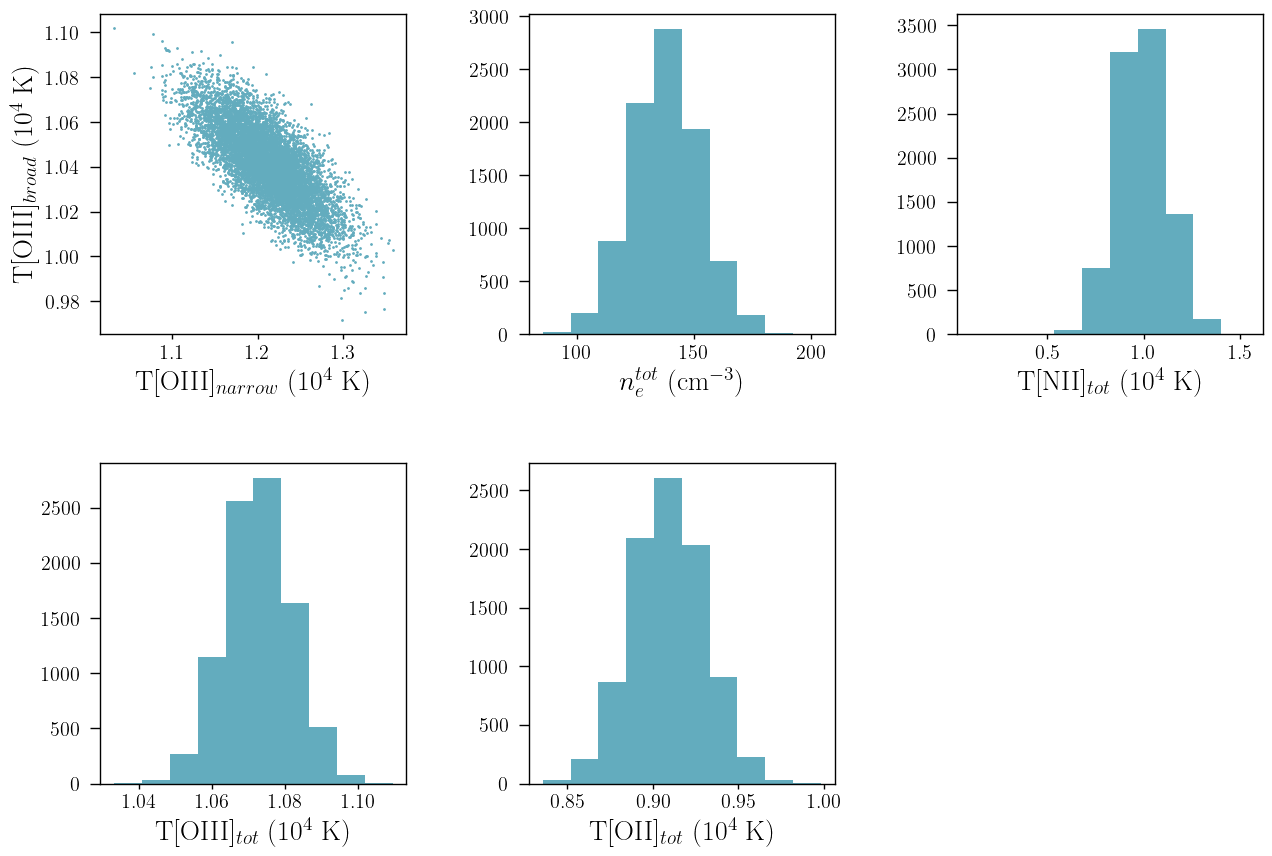

In [7]:
texPlot('on')
fig, axs = plt.subplots(2, 3)
fig.set_size_inches((15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0, 0].scatter(t_OIII_nar, t_OIII_brd, s=1, color=cr[2])
axs[0, 0].set_xlabel(r'T[OIII]$_{narrow}$ (10$^{4}$ K)')
axs[0, 0].set_ylabel(r'T[OIII]$_{broad}$ (10$^{4}$ K)')

axs[1, 0].hist(t_OIII_tot, color=cr[2])
axs[1, 0].set_xlabel(r'T[OIII]$_{tot}$ (10$^{4}$ K)')

axs[0, 1].hist(den_tot, color=cr[2])
axs[0, 1].set_xlabel(r'$n_{e}^{tot}$ (cm$^{-3}$)')

axs[1, 1].hist(t_OII_tot, color=cr[2])
axs[1, 1].set_xlabel(r'T[OII]$_{tot}$ (10$^{4}$ K)')

axs[1, 2].axis('off')

axs[0, 2].hist(t_NII_tot, color=cr[2])
axs[0, 2].set_xlabel(r'T[NII]$_{tot}$ (10$^{4}$ K)')

# Using Temperature relations derived by me

In [8]:
t_SIII_tot_temprel = (0.86 * t_OIII_tot) + 0.17

In [9]:
t_OIII_nar_mean = np.nanpercentile(t_OIII_nar, 50)
t_OIII_nar_16 = np.nanpercentile(t_OIII_nar, 16)
t_OIII_nar_84 = np.nanpercentile(t_OIII_nar, 84)

t_OIII_brd_mean = np.nanpercentile(t_OIII_brd, 50)
t_OIII_brd_16 = np.nanpercentile(t_OIII_brd, 16)
t_OIII_brd_84 = np.nanpercentile(t_OIII_brd, 84)

t_OIII_tot_mean = np.nanpercentile(t_OIII_tot, 50)
t_OIII_tot_16 = np.nanpercentile(t_OIII_tot, 16)
t_OIII_tot_84 = np.nanpercentile(t_OIII_tot, 84)

# Measured by me
t_OII = np.nanpercentile(t_OII_tot, 50)
t_OII_16 = np.nanpercentile(t_OII_tot, 16)
t_OII_84 = np.nanpercentile(t_OII_tot, 84)

# Photoionization models
t_OII_garnett = ((0.7 * (t_OIII_tot_mean * 10)) + 0.3) / 10
t_OII_garnett_16 = ((0.7 * (t_OIII_tot_16 * 10)) + 0.3) / 10
t_OII_garnett_84 = ((0.7 * (t_OIII_tot_84 * 10)) + 0.3) / 10

# Using PM
t_OII_PM = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot_mean**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))
t_OII_PM_16 = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot_16**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))
t_OII_PM_84 = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot_84**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))

# Linear
t_OII_lin = (0.27 * t_OIII_tot_mean) + 0.69
t_OII_lin_16 = (0.27 * t_OIII_tot_16) + 0.69
t_OII_lin_84 = (0.27 * t_OIII_tot_84) + 0.69

# Non-linear
t_OII_nlin = (2.4 / ((t_OIII_tot_mean**-1) + 1.5))
t_OII_nlin_16 = (2.4 / ((t_OIII_tot_16**-1) + 1.5))
t_OII_nlin_84 = (2.4 / ((t_OIII_tot_84**-1) + 1.5))

# Polynomial
t_OII_poly = (-6.6 * t_OIII_tot_mean) + (15.1 * (t_OIII_tot_mean**2)) + (-8.3 * (t_OIII_tot_mean**3)) + (0.69 * (t_OIII_tot_mean**5))
t_OII_poly_16 = (-6.6 * t_OIII_tot_16) + (15.1 * (t_OIII_tot_16**2)) + (-8.3 * (t_OIII_tot_16**3)) + (0.69 * (t_OIII_tot_16**5))
t_OII_poly_84 = (-6.6 * t_OIII_tot_84) + (15.1 * (t_OIII_tot_84**2)) + (-8.3 * (t_OIII_tot_84**3)) + (0.69 * (t_OIII_tot_84**5))

# Square-root
t_OII_sqrt = 0.3 + (0.66 * np.sqrt(t_OIII_tot_mean))
t_OII_sqrt_16 = 0.3 + (0.66 * np.sqrt(t_OIII_tot_16))
t_OII_sqrt_84 = 0.3 + (0.66 * np.sqrt(t_OIII_tot_84))

density = np.nanpercentile(den_tot, 50)
density_16 = np.nanpercentile(den_tot, 16)
density_84 = np.nanpercentile(den_tot, 84)

t_NII = np.nanpercentile(t_NII_tot, 50)
t_NII_16 = np.nanpercentile(t_NII_tot, 16)
t_NII_84 = np.nanpercentile(t_NII_tot, 84)

In [10]:
temden_dict = {'galname': galname,
               'tOIII_nar': t_OIII_nar_mean,
               'tOIII_nar_16': t_OIII_nar_16,
               'tOIII_nar_84': t_OIII_nar_84,
               'tOIII_brd': t_OIII_brd_mean,
               'tOIII_brd_16': t_OIII_brd_16,
               'tOIII_brd_84': t_OIII_brd_84,
               'tOIII_tot': t_OIII_tot_mean,
               'tOIII_tot_16': t_OIII_tot_16,
               'tOIII_tot_84': t_OIII_tot_84,
               'tOII': t_OII,
               'tOII_16': t_OII_16,
               'tOII_84': t_OII_84,
               'tOII_G92': t_OII_garnett,
               'tOII_G92_16': t_OII_garnett_16,
               'tOII_G92_84': t_OII_garnett_84,
               'tOII_PM': t_OII_PM,
               'tOII_PM_16': t_OII_PM_16,
               'tOII_PM_84': t_OII_PM_84,
               'tOII_lin': t_OII_lin,
               'tOII_lin_16': t_OII_lin_16,
               'tOII_lin_84': t_OII_lin_84,
               'tOII_nlin': t_OII_nlin,
               'tOII_nlin_16': t_OII_nlin_16,
               'tOII_nlin_84': t_OII_nlin_84,
               'tOII_poly': t_OII_poly,
               'tOII_poly_16': t_OII_poly_16,
               'tOII_poly_84': t_OII_poly_84,
               'tOII_sqrt': t_OII_sqrt,
               'tOII_sqrt_16': t_OII_sqrt_16,
               'tOII_sqrt_84': t_OII_sqrt_84,
               'ne': density,
               'ne_16': density_16,
               'ne_84': density_84,
               'tNII': t_NII,
               'tNII_16': t_NII_16,
               'tNII_84': t_NII_84,
               'tSIII': None,
               'tSIII_16': None,
               'tSIII_84': None,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_final2.csv')

Existent catalog (.csv) file.
Non existent data for J2101, adding new data...
Done.


# Abundances

In [11]:
# HELIUM

tau_4471 = 0.921 * E_BV * k_cal(wave_cat['HeI4471'])
tau_5875 = 0.921 * E_BV * k_cal(wave_cat['HeI5875'])
tau_6678 = 0.921 * E_BV * k_cal(wave_cat['HeI6678'])
tau_7065 = 0.921 * E_BV * k_cal(wave_cat['HeI7065'])

f_4471 = optical_depth_function(t_OIII_tot, den_tot, tau_4471, line='4471')
f_5875 = optical_depth_function(t_OIII_tot, den_tot, tau_5875, line='5875')
f_6678 = optical_depth_function(t_OIII_tot, den_tot, tau_6678, line='6678')
f_7065 = optical_depth_function(t_OIII_tot, den_tot, tau_7065, line='7065')

F4471, F5875, F6678, F7065 = emissivities(t_OIII_tot, den_tot)

y_plus_F4471 = yplus(chains['HeI4471'].to_numpy(), chains['Hb'].to_numpy(), F4471, f_4471)
y_plus_F5875 = yplus(chains['HeI5875'].to_numpy(), chains['Hb'].to_numpy(), F5875, f_5875)
y_plus_F6678 = yplus(chains['HeI6678'].to_numpy(), chains['Hb'].to_numpy(), F6678, f_6678)
y_plus_F7065 = yplus(chains['HeI7065'].to_numpy(), chains['Hb'].to_numpy(), F7065, f_7065)

y_plus = np.nanmean(np.array([y_plus_F4471,
                              y_plus_F5875,
                              y_plus_F6678,
                              y_plus_F7065]), axis=0)

y2_plus = y2plus(chains['HeII4686'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
y = y_plus + y2_plus

In [12]:
# OXYGEN MEASURED

log_O2plus_H_tot = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_tot = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot, den_tot)

O2plus_H_tot = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_tot = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot, den_tot) - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) * ICF_Oxygen
log_OH_tot = np.log10(O_H_tot) + 12

In [13]:
# OXYGEN GARNETT

log_O2plus_H_G92 = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_G92 = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_garnett, den_tot)

O2plus_H_G92 = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_G92 = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_garnett, den_tot) - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_G92 = (O2plus_H_G92 + Oplus_H_G92) * ICF_Oxygen
log_OH_G92 = np.log10(O_H_G92) + 12

In [14]:
# OXYGEN PM

log_O2plus_H_PM = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_PM = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_PM, den_tot)

O2plus_H_PM = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_PM = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_PM, den_tot) - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_PM = (O2plus_H_PM + Oplus_H_PM) * ICF_Oxygen
log_OH_PM = np.log10(O_H_PM) + 12

In [15]:
# OXYGEN lin

log_O2plus_H_lin = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_lin = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_lin, den_tot)

O2plus_H_lin = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_lin = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_lin, den_tot) - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_lin = (O2plus_H_lin + Oplus_H_lin) * ICF_Oxygen
log_OH_lin = np.log10(O_H_lin) + 12

In [16]:
# OXYGEN nlin

log_O2plus_H_nlin = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_nlin = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_nlin, den_tot)

O2plus_H_nlin = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_nlin = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_nlin, den_tot) - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_nlin = (O2plus_H_nlin + Oplus_H_nlin) * ICF_Oxygen
log_OH_nlin = np.log10(O_H_nlin) + 12

In [17]:
# OXYGEN poly

log_O2plus_H_poly = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_poly = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_poly, den_tot)

O2plus_H_poly = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_poly = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_poly, den_tot) - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_poly = (O2plus_H_poly + Oplus_H_poly) * ICF_Oxygen
log_OH_poly = np.log10(O_H_poly) + 12

In [18]:
# OXYGEN sqrt

log_O2plus_H_sqrt = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_sqrt = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_sqrt, den_tot)

O2plus_H_sqrt = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_sqrt = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_sqrt, den_tot) - 12)

ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_sqrt = (O2plus_H_sqrt + Oplus_H_sqrt) * ICF_Oxygen
log_OH_sqrt = np.log10(O_H_sqrt) + 12

In [19]:
# SULFUR

log_S2plus_H_tot = double_log_S_noline(chains['[SIII]6312'].to_numpy(), chains['Hb'].to_numpy(), t_SIII_tot_temprel)
log_Splus_H_tot = single_log_S(chains['[SII]6730'].to_numpy(), chains['[SII]6716'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot)

S2plus_H_tot = 10**(double_log_S_noline(chains['[SIII]6312'].to_numpy(), chains['Hb'].to_numpy(), t_SIII_tot_temprel) - 12)
Splus_H_tot = 10**(single_log_S(chains['[SII]6730'].to_numpy(), chains['[SII]6716'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot) - 12)

ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)

S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
log_SH_tot = np.log10(S_H_tot) + 12

In [20]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(chains['[NII]6584'].to_numpy(), chains['[NII]6548'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = np.log10(N_H_tot) + 12

In [21]:
# Nitrogen-to-Oxygen ratio
log_NO_tot = log_NO(chains['[NII]6584'].to_numpy(), chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), t_OII_tot)

(0.0, 1.0, 0.0, 1.0)

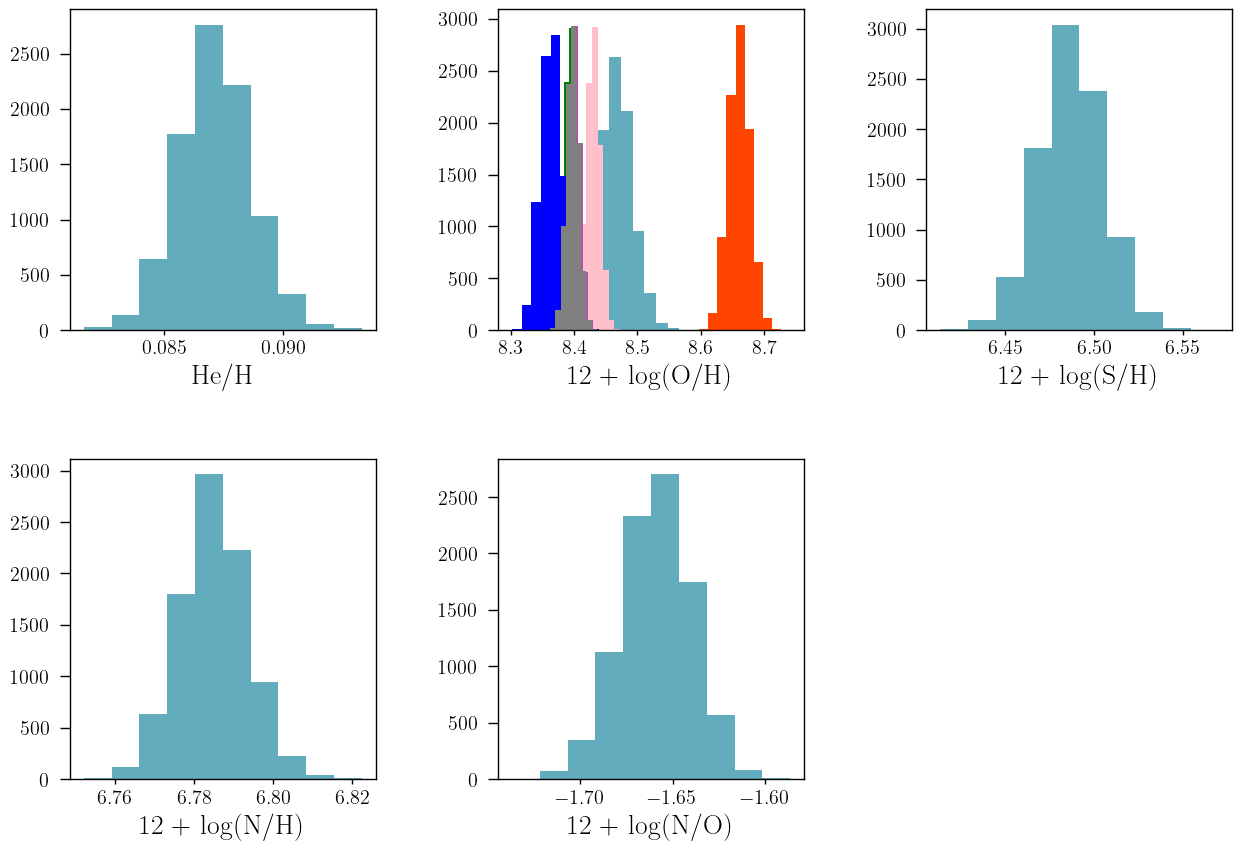

In [22]:
texPlot('on')
fig, axs = plt.subplots(2, 3)
fig.set_size_inches((15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0, 0].hist(y, color=cr[2])
axs[0, 0].set_xlabel(r'He/H')

axs[0, 1].hist(log_OH_tot, color=cr[2])
axs[0, 1].hist(log_OH_G92, color='Orangered')
axs[0, 1].hist(log_OH_PM, color='Pink')
axs[0, 1].hist(log_OH_lin, color=cz[1])
axs[0, 1].hist(log_OH_nlin, color='Green')
axs[0, 1].hist(log_OH_poly, color='Blue')
axs[0, 1].hist(log_OH_sqrt, color='Gray')
axs[0, 1].set_xlabel(r'12 + log(O/H)')

axs[0, 2].hist(log_SH_tot, color=cr[2])
axs[0, 2].set_xlabel(r'12 + log(S/H)')

axs[1, 0].hist(log_NH_tot, color=cr[2])
axs[1, 0].set_xlabel(r'12 + log(N/H)')

axs[1, 1].hist(log_NO_tot, color=cr[2])
axs[1, 1].set_xlabel(r'12 + log(N/O)')

axs[1, 2].axis('off')

In [23]:
He_tot_mean = np.nanpercentile(y, 50)
He_tot_16 = np.nanpercentile(y, 16)
He_tot_84 = np.nanpercentile(y, 84)

log_OH_tot_mean = np.nanpercentile(log_OH_tot, 50)
log_OH_tot_16 = np.nanpercentile(log_OH_tot, 16)
log_OH_tot_84 = np.nanpercentile(log_OH_tot, 84)

log_OH_G92_mean = np.nanpercentile(log_OH_G92, 50)
log_OH_G92_16 = np.nanpercentile(log_OH_G92, 16)
log_OH_G92_84 = np.nanpercentile(log_OH_G92, 84)

log_OH_PM_mean = np.nanpercentile(log_OH_PM, 50)
log_OH_PM_16 = np.nanpercentile(log_OH_PM, 16)
log_OH_PM_84 = np.nanpercentile(log_OH_PM, 84)

log_OH_lin_mean = np.nanpercentile(log_OH_lin, 50)
log_OH_lin_16 = np.nanpercentile(log_OH_lin, 16)
log_OH_lin_84 = np.nanpercentile(log_OH_lin, 84)

log_OH_nlin_mean = np.nanpercentile(log_OH_nlin, 50)
log_OH_nlin_16 = np.nanpercentile(log_OH_nlin, 16)
log_OH_nlin_84 = np.nanpercentile(log_OH_nlin, 84)

log_OH_poly_mean = np.nanpercentile(log_OH_poly, 50)
log_OH_poly_16 = np.nanpercentile(log_OH_poly, 16)
log_OH_poly_84 = np.nanpercentile(log_OH_poly, 84)

log_OH_sqrt_mean = np.nanpercentile(log_OH_sqrt, 50)
log_OH_sqrt_16 = np.nanpercentile(log_OH_sqrt, 16)
log_OH_sqrt_84 = np.nanpercentile(log_OH_sqrt, 84)

log_SH_tot_mean = np.nanpercentile(log_SH_tot, 50)
log_SH_tot_16 = np.nanpercentile(log_SH_tot, 16)
log_SH_tot_84 = np.nanpercentile(log_SH_tot, 84)

log_NH_tot_mean = np.nanpercentile(log_NH_tot, 50)
log_NH_tot_16 = np.nanpercentile(log_NH_tot, 16)
log_NH_tot_84 = np.nanpercentile(log_NH_tot, 84)

log_NO_tot_mean = np.nanpercentile(log_NO_tot, 50)
log_NO_tot_16 = np.nanpercentile(log_NO_tot, 16)
log_NO_tot_84 = np.nanpercentile(log_NO_tot, 84)

In [24]:
abundance_dict = {'galname': galname,
               'He/H': He_tot_mean,
               'He/H_16': He_tot_16,
               'He/H_84': He_tot_84,
               'log_OH': log_OH_tot_mean,
               'log_OH_16': log_OH_tot_16,
               'log_OH_84': log_OH_tot_84,
               'log_OH_G92': log_OH_G92_mean,
               'log_OH_G92_16': log_OH_G92_16,
               'log_OH_G92_84': log_OH_G92_84,
               'log_OH_PM': log_OH_PM_mean,
               'log_OH_PM_16': log_OH_PM_16,
               'log_OH_PM_84': log_OH_PM_84,
               'log_OH_lin': log_OH_lin_mean,
               'log_OH_lin_16': log_OH_lin_16,
               'log_OH_lin_84': log_OH_lin_84,
               'log_OH_nlin': log_OH_nlin_mean,
               'log_OH_nlin_16': log_OH_nlin_16,
               'log_OH_nlin_84': log_OH_nlin_84,
               'log_OH_poly': log_OH_poly_mean,
               'log_OH_poly_16': log_OH_poly_16,
               'log_OH_poly_84': log_OH_poly_84,
               'log_OH_sqrt': log_OH_sqrt_mean,
               'log_OH_sqrt_16': log_OH_sqrt_16,
               'log_OH_sqrt_84': log_OH_sqrt_84,
               'log_SH': log_SH_tot_mean,
               'log_SH_16': log_SH_tot_16,
               'log_SH_84': log_SH_tot_84,
               'log_NH': log_NH_tot_mean,
               'log_NH_16': log_NH_tot_16,
               'log_NH_84': log_NH_tot_84,
               'log_NO': log_NO_tot_mean,
               'log_NO_16': log_NO_tot_16,
               'log_NO_84': log_NO_tot_84,
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_final2.csv')

Existent catalog (.csv) file.
Non existent data for J2101, adding new data...
Done.


# Test for Starlight

(3300.0, 8000.0)

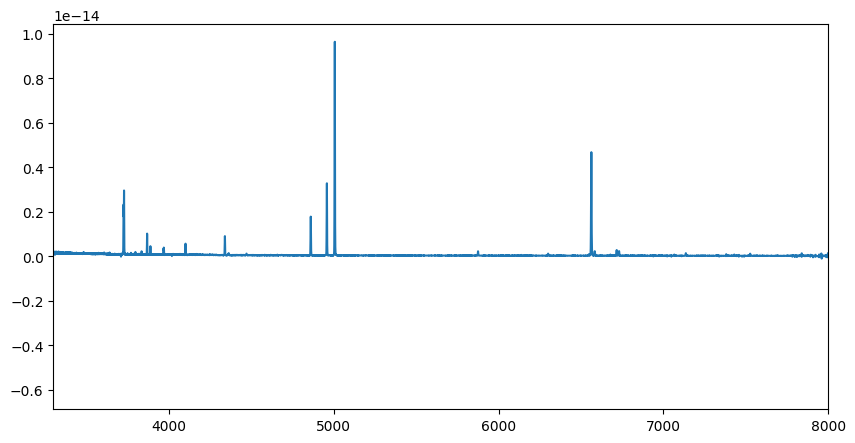

In [16]:
rf_wave = wave / (1 + z_nar_oiii_4959)
plt.figure(figsize=(10, 5))
plt.plot(rf_wave, flux)
plt.xlim(3300, 8000)

In [17]:
import spectres

rf_new_wave = np.arange(3300, 8000, 1)
new_flux, new_err = spectres.spectres(rf_new_wave, rf_wave, flux, err)

mask_flux = (new_flux > 0)

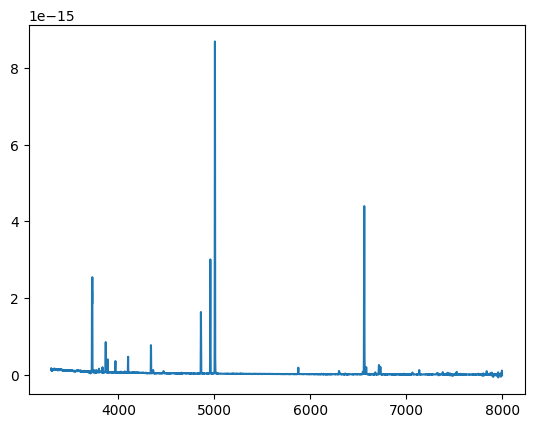

In [18]:
plt.plot(rf_new_wave, new_flux)

In [19]:
mask = False
mask_count = 0
mask_list = []
for line in wave_cat:
    if (wave_cat[line] > 3300) & (wave_cat[line] < 8000):
        sigma_line = (m * (wave_cat[line] * (1 + z_nar_oiii_4959))) + n
        sigma3 = 3 * np.sqrt(((upy.nominal_values(sigma_brd_intrinsic)**2) + (sigma_line**2)))
        lim_sup = wave_cat[line] + sigma3
        lim_inf = wave_cat[line] - sigma3
        mask_list.append([round(lim_inf), round(lim_sup)])
        mask_count += 1
        mask += (rf_new_wave > lim_inf) & (rf_new_wave < lim_sup)

In [20]:
with open('J2101_mask.cxt', 'a', newline='\n') as f:
    f.write(str(mask_count)+'\n')
    for masks in mask_list:
        f.write(str(masks[0])+' '+str(masks[1])+' '+'0\n')

In [23]:
from scipy.signal import medfilt
gpixs = np.where(abs(new_flux[~mask]-medfilt(new_flux[~mask],31))<0.4e-16)[0]

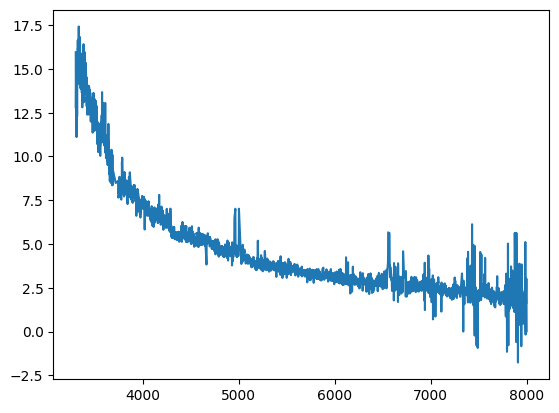

In [24]:
plt.plot(rf_new_wave[~mask][gpixs], new_flux[~mask][gpixs]/1e-17)
#plt.xlim(6500, 7000)
#plt.ylim(1e-16, 3e-16)

In [25]:
from astropy.io import ascii
for i in range(len(rf_new_wave)):
    if i in gpixs:
        flag = 0
    else:
        flag = 99
    spec_str = str(rf_new_wave[i])+' '+str(new_flux[i]/1e-17)+' '+str(new_err[i]/1e-17)+' '+str(flag)+'\n'
    with open('J2101.cxt', 'a', newline='\n') as f:
        f.write(spec_str)

In [26]:
FWHM(sigma_nar_oiii_4959, wave_cat['[OIII]4959'])

87.94299872787136

# After fitting

In [30]:
with open('/home/benjamin/Documents/STARLIGHTv04/J2101/J2101.cxt.sc4.C99.im.CAL.BS', 'r') as bf:
    # limits of lines to read
    line_lims = [531, 5232]
    # To store lines
    lines = []
    for i, line in enumerate(bf):
        # read lines inside limits
        if (i >= line_lims[0]) & (i <= line_lims[1]):
            lines.append(line.strip())
        elif i > 5232:
            # don't read after line 7 to save time
            break
print(lines)

['3300.00    4.85834   4.23466   -2.000', '3301.00    4.45370   4.19878    2.287', '3302.00    3.56293   4.18119    2.459', '3303.00    3.92797   4.17626    2.427', '3304.00    3.98886   4.17489    2.456', '3305.00    4.82359   4.17386   -2.000', '3306.00    3.73427   4.17285    2.632', '3307.00    3.55137   4.17183    2.624', '3308.00    3.66267   4.17082    2.703', '3309.00    3.10151   4.16981    2.747', '3310.00    4.07393   4.16879    2.746', '3311.00    3.44420   4.16778    2.911', '3312.00    3.89404   4.16674    2.998', '3313.00    3.77973   4.16514    2.981', '3314.00    4.13824   4.15764    3.008', '3315.00    3.43025   4.12950    3.161', '3316.00    4.41808   4.07169    3.141', '3317.00    4.40381   4.01391    3.160', '3318.00    4.43823   3.98583    3.191', '3319.00    3.95527   3.97839    3.277', '3320.00    3.94351   3.97693    3.260', '3321.00    4.46819   3.97682    3.252', '3322.00    4.64297   3.97864    3.245', '3323.00    4.41932   3.98122    3.348', '3324.00    4.5

In [31]:
wl = []
input_flux = []
best_model = []
for element in lines:
    wl.append(float(element.split()[0]))
    input_flux.append(float(element.split()[1]))
    best_model.append(float(element.split()[2]))

(0.0, 5.0)

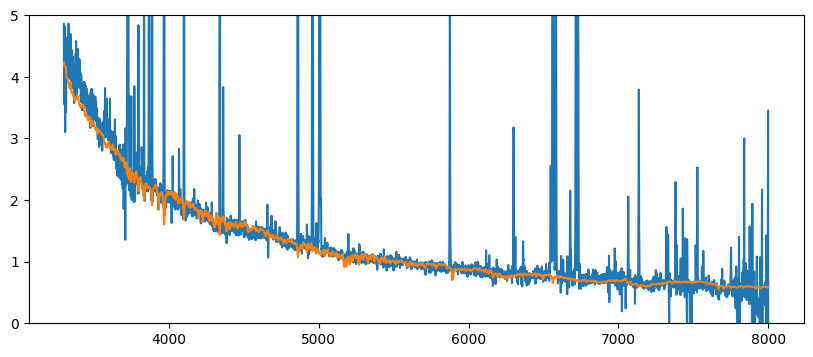

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(wl, input_flux)
plt.plot(wl, best_model)
#plt.xlim(4500, 5000)
plt.ylim(0, 5)

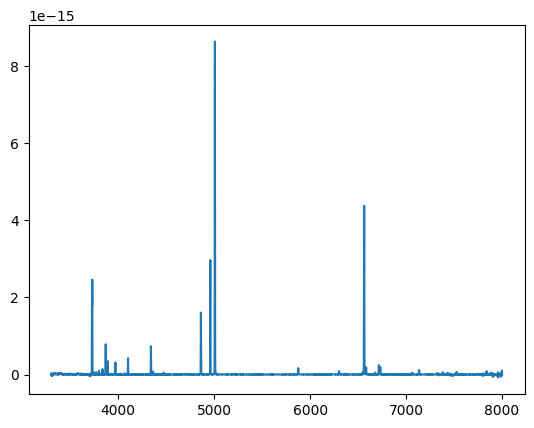

In [33]:
plt.plot(np.array(wl), (np.array(input_flux) - np.array(best_model)) * 3.582791E+00 * 1e-17)

In [34]:
np.log10(4.51621E+04 * 1e-17 * (1/3.826e33) * 4 * np.pi * ((3.04371e+27)**2))

10.138045568705545

In [15]:
z_nar_oiii_4959

0.19652130752330071

In [14]:
FWHM(sigma_nar_oiii_4959, wave_cat['[OIII]4959'])

87.94299872787136